### **London_House_Price_Prediction_ML_Pipeline**

In [2]:
import pandas as pd 
import numpy as np 
import category_encoders as ce
import shap
from scipy.stats import ttest_ind, randint, uniform

# plotting (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn core
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# preprocessing
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer

# encoding
from category_encoders import TargetEncoder

# models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR , LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.tree import DecisionTreeRegressor


from xgboost import XGBRegressor, plot_importance
from lightgbm import LGBMRegressor

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

## **Step 1 - Data Loading and Initial Cleaning**

In [3]:
df = pd.read_csv("Data/house_prices.csv")

In [4]:
df.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [5]:

# Remove Duplicate Observations

df = df.drop_duplicates().copy()

#Remove Leakage/Unused Columns

price_estimate_cols = [
    "rentEstimate_lowerPrice",
    "rentEstimate_currentPrice",
    "rentEstimate_upperPrice",
    "saleEstimate_lowerPrice",
    "saleEstimate_currentPrice",
    "saleEstimate_upperPrice",
    "saleEstimate_confidenceLevel",
    "saleEstimate_ingestedAt",
    "saleEstimate_valueChange.numericChange",
    "saleEstimate_valueChange.percentageChange",
    "saleEstimate_valueChange.saleDate",
    "history_percentageChange",
    "history_numericChange"
]

country_cols = [
    "country"
]

location_cols = [
    "fullAddress",
    "postcode"
]

drop_cols = price_estimate_cols + country_cols + location_cols

df_ml = df.drop(columns=drop_cols, errors="ignore").copy()

# Convert Date Columns 

df_ml["history_date"] = pd.to_datetime(df_ml["history_date"], errors="coerce")

# Temporal Feature Engineering 

df_ml["sale_year"] = df_ml["history_date"].dt.year
df_ml["years_since_sale"] = 2026 - df_ml["sale_year"]
df_ml["sale_month"] = df_ml["history_date"].dt.month

# Structural Feature Engineering 

df_ml["total_rooms"] = df_ml["bedrooms"] + df_ml["livingRooms"]

df_ml["bathrooms_per_bedroom"] = np.where(
    df_ml["bedrooms"] > 0,
    df_ml["bathrooms"] / df_ml["bedrooms"],
    np.nan
)

df_ml["sqm_per_room"] = np.where(
    df_ml["total_rooms"] > 0,
    df_ml["floorAreaSqM"] / df_ml["total_rooms"],
    np.nan
)

# Geographic Feature Engineering 
df_ml["lat_lon_interaction"] = df_ml["latitude"] * df_ml["longitude"]

#Final Cleanup
df_ml = df_ml.drop(columns = 'history_date')



In [6]:
# Add distance to central London
# Geographic Distance Features


def haversine_distance(lat1, lon1, lat2, lon2): #earth is curved
    """
    Calculate distance between two lat/lon points in kilometres.
    """
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat1 - lat2
    dlon = lon1 - lon2

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat2) * np.cos(lat1) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [7]:
# Central London coordinates
central_london_lat = 51.5074
central_london_lon = -0.1278

# Add new feature to your full dataset BEFORE splitting
df_ml["distance_to_central_london_km"] = haversine_distance(
    df_ml["latitude"],
    df_ml["longitude"],
    central_london_lat,
    central_london_lon
)

In [8]:
#Check the calculation has worked

df_ml['distance_to_central_london_km'].describe()

count    418194.000000
mean          7.934181
std           3.948829
min           0.077540
25%           4.796187
50%           8.033149
75%          10.840750
max          19.663539
Name: distance_to_central_london_km, dtype: float64

In [9]:
df_ml.head()

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_price,sale_year,years_since_sale,sale_month,total_rooms,bathrooms_per_bedroom,sqm_per_room,lat_lon_interaction,distance_to_central_london_km
0,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,NaN,830000,1995,31,1,2.0,1.00,22.500000,-5.683098,1.634534
1,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,830000,1995,31,1,NaN,NaN,NaN,-5.683098,1.634534
2,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,249950,1995,31,1,3.0,1.00,23.666667,-6.816929,1.360143
3,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,32000,1995,31,1,2.0,1.00,32.000000,-4.746361,4.077599
4,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,133000,1995,31,1,6.0,0.25,22.833333,-7.201757,9.085086


In [10]:
#Missing Value Summary
df_ml.isna().sum()

outcode                              0
latitude                             0
longitude                            0
bathrooms                        77930
bedrooms                         40535
floorAreaSqM                     25209
livingRooms                      60499
tenure                           11512
propertyType                      1136
currentEnergyRating              84526
history_price                        0
sale_year                            0
years_since_sale                     0
sale_month                           0
total_rooms                      64969
bathrooms_per_bedroom            82580
sqm_per_room                     76163
lat_lon_interaction                  0
distance_to_central_london_km        0
dtype: int64

## **Step 2 - Train, Validation and Test Split**

The dataset was divided into training, validation, and test sets before preprocessing and modelling to reduce the risk of data leakage.

In [11]:
#Seperate Features (X) and Target Variable (y)

X = df_ml.drop(columns = 'history_price')
y = df_ml['history_price']

In [12]:
# Initial Train/Test Split

# Reserve 20% of the dataset for final testing

X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size = 0.2, random_state = 9)

In [13]:
#Training and Validation Split

#Split remaining data into:
#Training set (60% overall)
#Validation set (20% overall)

X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp, test_size = 0.25, random_state=9)

In [14]:
#Verify Dataset Split Proportions
print("Train:", round(len(X_train) / len(X), 2))
print("Val:", round(len(X_val) / len(X), 2))
print("Test:", round(len(X_test) / len(X), 2))

Train: 0.6
Val: 0.2
Test: 0.2


In [15]:
# Verify Target Distribution Across Splits
print("Train mean:", y_train.mean())
print("Val mean:", y_val.mean())
print("Test mean:", y_test.mean())

Train mean: 642033.2866297885
Val mean: 634290.7603390763
Test mean: 637543.1577135068


# **Step 3 - Experiment 1: Baseline Modelling**


Initial baseline experiments were conducted using complete-case analysis with no imputation or advanced feature engineering. The outcode variable was removed at this stage to establish a simpler baseline framework using only numeric variables and one-hot encoded categorical features.

The primary aim of this experiment was to compare the performance of several baseline regression models before introducing more advanced preprocessing, geographic encoding, and ensemble modelling techniques.

In [16]:
#3.1 Remove Outcode Variable and Missing Values

# Complete-case analysis was applied after dataset splitting
# to avoid data leakage and preserve consistency across splits.

# Remove Outcode Variable 

X_train_exp1 = X_train.drop(columns=["outcode"], errors="ignore")
X_val_exp1 = X_val.drop(columns=["outcode"], errors="ignore")
X_test_exp1 = X_test.drop(columns=["outcode"], errors="ignore")

# Remove Missing Values (Complete Case Analysis)

train_mask = X_train_exp1.notna().all(axis=1)
val_mask = X_val_exp1.notna().all(axis=1)
test_mask = X_test_exp1.notna().all(axis=1)

X_train_exp1 = X_train_exp1[train_mask]
y_train_exp1 = y_train[train_mask]

X_val_exp1 = X_val_exp1[val_mask]
y_val_exp1 = y_val[val_mask]

X_test_exp1 = X_test_exp1[test_mask]
y_test_exp1 = y_test[test_mask]




In [17]:
# Check Proportion of Complete Cases Retained
train_prop = len(X_train_exp1) / len(X_train)
val_prop   = len(X_val_exp1) / len(X_val)
test_prop  = len(X_test_exp1) / len(X_test)

print("Train proportion kept:", train_prop)
print("Val proportion kept:", val_prop)
print("Test proportion kept:", test_prop)

Train proportion kept: 0.637017966171946
Val proportion kept: 0.6355288800679109
Test proportion kept: 0.6369875297409103


In [18]:
# Verify Target Distribution After Complete Case Filtering
print(y_train_exp1.mean(), y_val_exp1.mean(), y_test_exp1.mean())

579455.1440771281 570134.8648668987 571797.8108940067


In [19]:
#Inspect Feature Data Types
for col in X_train_exp1.columns:
    print(f"{col}: {X_train_exp1[col].dtype}")

latitude: float64
longitude: float64
bathrooms: float64
bedrooms: float64
floorAreaSqM: float64
livingRooms: float64
tenure: object
propertyType: object
currentEnergyRating: object
sale_year: int32
years_since_sale: int32
sale_month: int32
total_rooms: float64
bathrooms_per_bedroom: float64
sqm_per_room: float64
lat_lon_interaction: float64
distance_to_central_london_km: float64


In [20]:
# Define Numerical and Categorical Features

numerical_cols = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "sale_year",
    "years_since_sale",
    "sale_month",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "lat_lon_interaction",
]

categorical_cols = [
    "tenure",
    "propertyType",
    "currentEnergyRating"
]


In [21]:
# Dummy Regressor Pipeline, Experiment 1

# Preprocessing Pipeline
preprocessor_dummy = ColumnTransformer([
    ("num", "passthrough",numerical_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Dummy Regression Pipeline
dummy_model = Pipeline([
    ('preprocess',preprocessor_dummy),
    ('model', DummyRegressor())
])


In [22]:
#Fit Dummy Regressor
dummy_model.fit(X_train_exp1,y_train_exp1)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['latitude', 'longitude',
                                                   'bathrooms', 'bedrooms',
                                                   'floorAreaSqM',
                                                   'livingRooms', 'sale_year',
                                                   'years_since_sale',
                                                   'sale_month', 'total_rooms',
                                                   'bathrooms_per_bedroom',
                                                   'sqm_per_room',
                                                   'lat_lon_interaction']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['tenure', 'propertyType',
                                                   'currentEnergyRating'])])),
                ('model', DummyRegressor())])

In [23]:
# Generate Predictions
y_train_pred= dummy_model.predict(X_train_exp1)
y_val_pred =  dummy_model.predict(X_val_exp1)

In [24]:
# Evaluate Model Performance

mse_train = mean_squared_error(y_train_exp1, y_train_pred)
mse_val   = mean_squared_error(y_val_exp1, y_val_pred)

rmse_train = np.sqrt(mse_train)
rmse_val   = np.sqrt(mse_val)

print("Train RMSE:", rmse_train)
print("Validation RMSE:", rmse_val)


Train RMSE: 786014.426921837
Validation RMSE: 791359.0062112225


The Dummy Regressor provides the baseline benchmark for Experiment 1. Since it predicts the mean house price for every observation, any useful machine learning model should achieve a lower validation RMSE than this value.

In [25]:
#Mean Dummy Prediction
y_train_pred.mean()

np.float64(579455.1440771281)

In [26]:
#  Mean Training Target Value
y_train_exp1.mean()

np.float64(579455.1440771281)

## 3.2 Define Baseline Models

In [27]:
#Baseline Modelling Preprocessing Pipelines

# Preprocessing pipleline without feature scaling

preprocessor_no_scale = ColumnTransformer([
    ("num", "passthrough", numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Preprocessing pipeline with numerical feature scaling
preprocessor_scale = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [28]:
# Define Baseline Models 


models = {

    # Dummy Regressor

    "Dummy": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", DummyRegressor())
    ]),

    # Linear Regression Models

    "Linear_No_Scale": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", LinearRegression())
    ]),

    "Linear_Scaled": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LinearRegression())
    ]),

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(cv=5,random_state=9, max_iter=10000))
    ]),

    "Ridge": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 20)
        ))
    ]),

    # Nonlinear Models

    "DecisionTree": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", DecisionTreeRegressor(random_state=9
        ))
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", KNeighborsRegressor())
    ]),

    "SVR": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LinearSVR( random_state=9,max_iter=10000))
    ])
}

In [29]:
#Train and Evaluate Baseline Models

results = []

for name, model in models.items():
    model.fit(X_train_exp1, y_train_exp1)
    
    y_train_pred = model.predict(X_train_exp1)
    y_val_pred = model.predict(X_val_exp1)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_exp1, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_val_exp1, y_val_pred))
    
    results.append({
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val
    })

# Results table

results_df = pd.DataFrame(results)

# sort by best validation RMSE
results_df = results_df.sort_values(by="Validation_RMSE", ascending=True).reset_index(drop=True)
results_df["RMSE_Gap"] = results_df["Validation_RMSE"] - results_df["Train_RMSE"]

print(results_df)

             Model     Train_RMSE  Validation_RMSE       RMSE_Gap
0              KNN  379804.216207    485364.565765  105560.349557
1     DecisionTree   54328.887042    491519.477814  437190.590771
2            Lasso  575895.887772    597217.345313   21321.457541
3  Linear_No_Scale  575601.802953    597432.674502   21830.871550
4    Linear_Scaled  575601.802953    597432.674502   21830.871550
5            Ridge  575601.812808    597432.852029   21831.039221
6            Dummy  786014.426922    791359.006211    5344.579289
7              SVR  817339.637235    820135.407991    2795.770755


## 3.3 Experiment 1 - Conclusion and Model Selection

Nonlinear models substantially outperformed linear approaches during the initial baseline experiments, suggesting that London house prices contain complex nonlinear relationships that are not fully captured by simple linear models. K-Nearest-Neighbours achieved the lowest validation RMSE overall, while Decision Tree models also produced strong predictive performance but showed substantial overfitting, reflected by the very large train-validation RMSE gap.

In contrast, Lasso and Ridge regression models produced weaker predictive performance but demonstrated more stable generalisation behaviour with relatively small RMSE gaps. Support Vector Regression performed poorly relative to all other approaches and was not investigated further in later experiments.

Based on these findings, KNN, Decision Tree, and regularised linear models were retained for further experimentation.


## Step 4 - Experiment 2: Geographic Encoding (Add Outcode)

This experiment introduced the outcode variable using target encoding to better capture local geographic pricing patterns within the London housing market. Complete case analysis was retained from Experiment 1, with rows containing missing values removed prior to modelling.

The primary aim of this experiment was to evaluate whether geographic encoding could improve predictive performance relative to the earlier baseline models

In [30]:
# Complete case dataset with Outcode Retained

X_train_exp2 = X_train.copy()
X_val_exp2 = X_val.copy()
X_test_exp2 = X_test.copy()

# Remove Missing Values (Complete Case Analysis)
train_mask = X_train_exp2.notna().all(axis=1)
val_mask = X_val_exp2.notna().all(axis=1)
test_mask = X_test_exp2.notna().all(axis=1)

X_train_exp2 = X_train_exp2[train_mask]
y_train_exp2 = y_train[train_mask]

X_val_exp2 = X_val_exp2[val_mask]
y_val_exp2 = y_val[val_mask]

X_test_exp2 = X_test_exp2[test_mask]
y_test_exp2 = y_test[test_mask]

In [31]:
#Target Encoding Columns

target_encode_cols_exp2 = ["outcode"]

In [32]:

# Preprocessing Pipelines with Target Encoding


preprocessor_no_scale_exp2 = ColumnTransformer([
    ("num", "passthrough", numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("outcode_te", ce.TargetEncoder(), ["outcode"])
])

preprocessor_scale_exp2 = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("outcode_te", ce.TargetEncoder(), ["outcode"])
])

In [33]:
models_exp2 = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale_exp2),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "DecisionTree": Pipeline([
        ("preprocess", preprocessor_no_scale_exp2),
        ("model", DecisionTreeRegressor(
            random_state=9
        ))
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocessor_scale_exp2),
        ("model", KNeighborsRegressor())
    ])
}

At this stage, the primary aim of the experiment was to evaluate whether target encoding of the outcode variable improved predictive performance relative to the earlier baseline models. Since Experiment 1 had already established that nonlinear approaches substantially outperformed simpler linear methods, only a smaller subset of representative models was retained for further experimentation. This included a regularised linear model (Lasso) as a stable benchmark alongside Decision Tree and KNN models, which had previously demonstrated the strongest predictive performance.

In [34]:
#Train and Evaluate Experiment 2 Models
results_exp2 = []

for name, model in models_exp2.items():
    model.fit(X_train_exp2, y_train_exp2)
    
    y_train_pred = model.predict(X_train_exp2)
    y_val_pred = model.predict(X_val_exp2)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_exp2, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_val_exp2, y_val_pred))
    
    results_exp2.append({
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val
    })



In [35]:

# Create Results table

results_exp2_df = pd.DataFrame(results_exp2)

# sort by best validation RMSE
results_exp2_df = results_exp2_df.sort_values(by="Validation_RMSE", ascending=True).reset_index(drop=True)

# add gap
results_exp2_df["RMSE_Gap"] = (
    results_exp2_df["Validation_RMSE"] - results_exp2_df["Train_RMSE"]
)
pd.options.display.float_format = '{:,.0f}'.format
print(results_exp2_df)

          Model  Train_RMSE  Validation_RMSE  RMSE_Gap
0           KNN     357,344          459,097   101,753
1  DecisionTree      54,329          459,128   404,799
2         Lasso     716,197          727,482    11,285


## Experiment 2 Findings


Introducing target encoding for the outcode variable improved predictive performance for the nonlinear models relative to Experiment 1. KNN achieved the strongest validation RMSE overall, improving from approximately £485,000 to £459,000, while the Decision Tree validation RMSE also improved substantially despite continued overfitting.

In contrast, Lasso regression performance deteriorated noticeably after the introduction of target encoding, suggesting that the additional geographic information was more effectively utilised by nonlinear models than by regularised linear approaches.

These findings further highlighted the importance of geographic information within London house price prediction

## Step 5 - Experiment 3: Missing Value Imputation (Instead of dropping Nans)

Previous experiments used complete-case analysis by removing observations containing missing values. This experiment instead investigated whether predictive performance could be improved through imputation while retaining a larger proportion of the dataset.

Several imputation strategies were tested, including median imputation for numerical variables, most-frequent-category imputation for categorical variables, explicit missing-category assignment, and KNN imputation. The primary aim was to evaluate whether retaining incomplete observations improved model performance relative to the earlier complete-case approaches.

For this experiment and future comparison experiments KNN was removed as it is computationally expensive and takes a substantial period of time to run each segment of code

In [36]:
# Experiment 3: Retain Full Dataset for Imputation Experiments

X_train_exp3 = X_train.copy()
X_val_exp3 = X_val.copy()
X_test_exp3 = X_test.copy()

y_train_exp3 = y_train.copy()
y_val_exp3 = y_val.copy()
y_test_exp3 = y_test.copy()

In [37]:
#Missing Value Summary
missing_summary = (
    df_ml.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary[missing_summary > 0]

currentEnergyRating      84526
bathrooms_per_bedroom    82580
bathrooms                77930
sqm_per_room             76163
total_rooms              64969
livingRooms              60499
bedrooms                 40535
floorAreaSqM             25209
tenure                   11512
propertyType              1136
dtype: int64

In [38]:
#Show average price of houses where there is missingness
## Investigate Missingness and Target Relationship
col = "tenure"  # Example Variable

temp = X_train[[col]].copy()
temp["target"] = y_train

# create missing indicator
temp["is_missing"] = temp[col].isna()

# compare average target
result = temp.groupby("is_missing")["target"].mean()

print(result)

is_missing
False   634,932
True    894,702
Name: target, dtype: float64


In [39]:
# Investigate Missingness and Target Relationship
col = "currentEnergyRating"  # Example Variable

temp = X_train[[col]].copy()
temp["target"] = y_train

# create missing indicator
temp["is_missing"] = temp[col].isna()

# compare average target
result = temp.groupby("is_missing")["target"].mean()

print(result)

is_missing
False   625,429
True    707,783
Name: target, dtype: float64


In [40]:
col = "propertyType"  # Example Variable

temp = X_train[[col]].copy()
temp["target"] = y_train

# create missing indicator
temp["is_missing"] = temp[col].isna()

# compare average target
result = temp.groupby("is_missing")["target"].mean()

print(result)

is_missing
False     640,811
True    1,099,937
Name: target, dtype: float64


In [41]:


cols = ["tenure", "currentEnergyRating", "propertyType"]

results = []

for col in cols:
    group_not_missing = y_train[~X_train[col].isna()]
    group_missing = y_train[X_train[col].isna()]
    
    # only run if there are missing values
    if len(group_missing) > 0:
        t_stat, p_value = ttest_ind(group_not_missing, group_missing, equal_var=False)
        
        results.append({
            "Column": col,
            "Mean_Not_Missing": group_not_missing.mean(),
            "Mean_Missing": group_missing.mean(),
            "Difference": group_missing.mean() - group_not_missing.mean(),
            "P_Value": p_value
        })

ttest_df = pd.DataFrame(results)

# sort by biggest difference
ttest_df = ttest_df.sort_values(by="Difference", key=abs, ascending=False)

pd.options.display.float_format = '{:,.0f}'.format
print(ttest_df)

                Column  Mean_Not_Missing  Mean_Missing  Difference  P_Value
2         propertyType           640,811     1,099,937     459,126        0
0               tenure           634,932       894,702     259,769        0
1  currentEnergyRating           625,429       707,783      82,354        0



Exploratory data analysis was conducted exclusively on the training dataset to reduce the risk of data leakage. Missing-value analysis revealed statistically significant differences in house prices between missing and non-missing groups, suggesting that missingness was systematic rather than random and therefore likely contained useful predictive information.

In [46]:

# Experiment 3A - Imputation Pipelines
# Numerical = Median Imputation
# Categorical = Most Frequent Imputation
# Outcode = Target Encoding


num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

outcode_pipeline = Pipeline([
    ("target_encoder", ce.TargetEncoder())
])

In [47]:

# Experiment 3A - Preprocessing Pipelines


# Preprocessing pipeline without scaling
preprocessor_no_scale = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])

# Preprocessing pipeline with scaling
preprocessor_scale = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),

    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])

In [48]:
# ============================================================
# Function to Evaluate Imputation Setups
# ============================================================

def run_missing_data_setup(
    preprocessor_no_scale,
    preprocessor_scale,
    setup_name
):

    # --------------------------------------------------------
    # Define Models
    # --------------------------------------------------------

    models = {

        "Lasso": Pipeline([
            ("preprocess", preprocessor_scale),
            ("model", LassoCV(
                cv=5,
                random_state=9,
                max_iter=10000
            ))
        ]),

        "DecisionTree": Pipeline([
            ("preprocess", preprocessor_no_scale),
            ("model", DecisionTreeRegressor(
                random_state=9
            ))
        ])
    }


    # --------------------------------------------------------
    # Train and Evaluate Models
    # --------------------------------------------------------

    results = []

    for name, model in models.items():

        model.fit(X_train_exp3, y_train_exp3)

        y_train_pred = model.predict(X_train_exp3)

        y_val_pred = model.predict(X_val_exp3)

        rmse_train = np.sqrt(
            mean_squared_error(y_train_exp3, y_train_pred)
        )

        rmse_val = np.sqrt(
            mean_squared_error(y_val_exp3, y_val_pred)
        )

        results.append({
            "Setup": setup_name,
            "Model": name,
            "Train_RMSE": rmse_train,
            "Validation_RMSE": rmse_val,
            "Overfit_Gap": rmse_val - rmse_train
        })


    # --------------------------------------------------------
    # Return Results
    # --------------------------------------------------------

    return pd.DataFrame(results)

In [49]:

# 5. RUN SETUP 1
# Numerical = Median Imputation
# Categorical = Most Frequent Imputation

results_setup1 = run_missing_data_setup(
    preprocessor_no_scale,
    preprocessor_scale,
    "Setup_1_NumMedian_Cat_mostfrequent"
)

results_setup1


,Setup,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Setup_1_NumMedian_Cat_mostfrequent,Lasso,"1,239,190","1,334,576","95,387"
1,Setup_1_NumMedian_Cat_mostfrequent,DecisionTree,"82,407","1,077,708","995,301"


In [50]:

#Experiment 3B - 
# Setup 2
# Numerical = Median Imputation
# Categorical = Explicit Missing Category
# Outcode = Missing Category + Target Encoding


num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

outcode_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("target_encoder", TargetEncoder())
])


# Preprocessing Pipelines

# Preprocessing pipeline without scaling
preprocessor_no_scale = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])

# Preprocessing pipeline with scaling
preprocessor_scale = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),

    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])

In [51]:

# Run Setup 2
# Numerical = Median Imputation
# Categorical = Explicit Missing Category


results_setup2 = run_missing_data_setup(
    preprocessor_no_scale,
    preprocessor_scale,
    "Median_Num_MissingCategory_Cat"
)

results_setup2

,Setup,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Median_Num_MissingCategory_Cat,Lasso,"1,239,190","1,334,576","95,387"
1,Median_Num_MissingCategory_Cat,DecisionTree,"82,360","1,103,476","1,021,116"


In [52]:

# Setup 3
# Numerical = KNN Imputation
# Categorical = Most Frequent Imputation
# Outcode = Target Encoding


# Reduced Sample for KNN Imputation


# KNN imputation is computationally expensive on the full dataset, so a reduced training sample is used.

X_train_knn = X_train_exp3.sample(
    n=20000,
    random_state=9
)

y_train_knn = y_train_exp3.loc[X_train_knn.index]


# Numerical Pipeline


num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])


# Categorical Pipeline


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Outcode Pipeline


outcode_pipeline = Pipeline([
    ("target_encoder", ce.TargetEncoder())
])



# Preprocessing Pipelines


# Preprocessing pipeline without scaling
preprocessor_no_scale = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])

# Preprocessing pipeline with scaling
preprocessor_scale = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]), numerical_cols),

    ("cat", cat_pipeline, categorical_cols),
    ("outcode_te", outcode_pipeline, ["outcode"])
])



# Run Setup 3


results_setup3 = []

models = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "DecisionTree": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", DecisionTreeRegressor(
            random_state=9
        ))
    ])
}


for name, model in models.items():

    # Fit model on reduced KNN sample
    model.fit(X_train_knn, y_train_knn)

    
    # Predictions
    y_train_pred = model.predict(X_train_knn)

    y_val_pred = model.predict(X_val_exp3)

    
    # RMSE
    rmse_train = np.sqrt(
        mean_squared_error(y_train_knn, y_train_pred)
    )

    rmse_val = np.sqrt(
        mean_squared_error(y_val_exp3, y_val_pred)
    )

    
    # Store results
    results_setup3.append({
        "Setup": "KNN_Num_MostFrequent_Cat",
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val,
        "Overfit_Gap": rmse_val - rmse_train
    })



# Results Table


results_setup3 = pd.DataFrame(results_setup3)

results_setup3

,Setup,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,KNN_Num_MostFrequent_Cat,Lasso,"1,196,628","1,344,164","147,537"
1,KNN_Num_MostFrequent_Cat,DecisionTree,"55,192","1,596,547","1,541,356"


In [53]:
print(y_train.describe())

count       250,916
mean        642,033
std       1,316,299
min          10,000
25%         229,288
50%         400,000
75%         665,020
max     105,800,000
Name: history_price, dtype: float64




### Experiment 3 Findings

All imputation approaches substantially reduced predictive performance relative to the earlier complete-case experiments. Validation RMSE values increased considerably across both Lasso and Decision Tree models, while Decision Trees also displayed extreme overfitting under all imputation setups.

Median imputation combined with most-frequent-category imputation and explicit missing-category assignment produced similarly poor results, suggesting that missing structural housing characteristics could not be reliably inferred from the available variables. KNN imputation performed worst overall and introduced substantial additional overfitting while also being computationally expensive on larger datasets.

These findings suggest that missingness within the dataset was systematic rather than random and likely contained predictive information related to property value. As a result, subsequent experiments continued using complete-case analysis rather than imputation approaches.



## Step 6 - Experiment 4: Log-Tranformed Target Variable. 


Exploratory data analysis showed that house prices were heavily positively skewed with substantial luxury-property outliers. This experiment therefore investigated whether applying a log transformation to the target variable improved predictive performance and model stability by reducing the influence of extreme observations.

The log-transformed target variable was evaluated using complete-case analysis following the findings from Experiment 3, where imputation approaches consistently reduced predictive performance.

In [54]:

# Experiment 4
# Log-Transformed Target Variable
# Complete-Case Analysis
# Target-Encoded Outcode Retained



# Apply log transformation to target variable
y_train_log = np.log1p(y_train_exp2)

y_val_log = np.log1p(y_val_exp2)



# Define Models


models_log = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale_exp2),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "DecisionTree": Pipeline([
        ("preprocess", preprocessor_no_scale_exp2),
        ("model", DecisionTreeRegressor(
            random_state=9
        ))
    ])
}



# Train and Evaluate Models


results_log = []

for name, model in models_log.items():


    model.fit(X_train_exp2, y_train_log)

    
   

    y_train_pred_log = model.predict(X_train_exp2)

    y_val_pred_log = model.predict(X_val_exp2)

    

    y_train_pred = np.expm1(y_train_pred_log)

    y_val_pred = np.expm1(y_val_pred_log)

   

    rmse_train = np.sqrt(
        mean_squared_error(y_train_exp2, y_train_pred)
    )

    rmse_val = np.sqrt(
        mean_squared_error(y_val_exp2, y_val_pred)
    )

    


    results_log.append({
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val,
        "Overfit_Gap": rmse_val - rmse_train
    })




results_log = (
    pd.DataFrame(results_log)
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

results_log



,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,DecisionTree,"58,143","489,690","431,547"
1,Lasso,"492,629","515,537","22,908"


### Experiment 4 Findings

Applying a log transformation to the target variable produced mixed results across the shortlisted models. The Lasso model improved substantially, reducing validation RMSE from approximately £727,000 to £516,000, suggesting that linear models benefited from the more symmetric target distribution and reduced influence of extreme luxury-property observations.

In contrast, the Decision Tree model showed little improvement relative to Experiment 2 and continued to display substantial overfitting. The strongest nonlinear models from Experiment 2 therefore remained superior overall despite the reduction in target skewness.

These findings suggested that future modelling stages should focus less on target transformation alone and more on reducing overfitting and handling extreme market variation through approaches such as outlier trimming, ensemble modelling, and market segmentation.

## Step 7 - Experiment 5: Log Transformation & Outlier Trimming

Previous experiments demonstrated that nonlinear models achieved the strongest predictive performance overall but continued to suffer from substantial overfitting, likely driven by the extreme variability present within high-value London properties.

This experiment therefore investigated whether trimming extreme target outliers improved model stability and generalisation performance. Complete-case analysis and target-encoded outcodes were retained from earlier experiments, while the target variable remained log-transformed following the improvements observed for linear models in Experiment 4.

Two outlier thresholds were tested by removing the top 1% and top 5% of house prices from the training data prior to modelling. The primary aim was to evaluate whether reducing the influence of extreme luxury property observations improved predictive performance and reduced overfitting within nonlinear models.

In [55]:
# ============================================================
# Experiment 5
# Log Target + Outlier Trimming
# ============================================================

def run_exp5_with_trimming(
    trim_quantile,
    experiment_name,
    trim_validation=False
):

    # --------------------------------------------------------
    # Copy Data
    # --------------------------------------------------------

    X_train_exp5 = X_train.copy()
    X_val_exp5 = X_val.copy()

    y_train_exp5 = y_train.copy()
    y_val_exp5 = y_val.copy()


    # --------------------------------------------------------
    # Complete-Case Analysis
    # --------------------------------------------------------

    train_mask = X_train_exp5.notna().all(axis=1)

    val_mask = X_val_exp5.notna().all(axis=1)

    X_train_exp5 = X_train_exp5[train_mask]
    y_train_exp5 = y_train_exp5[train_mask]

    X_val_exp5 = X_val_exp5[val_mask]
    y_val_exp5 = y_val_exp5[val_mask]


    # --------------------------------------------------------
    # Remove Top Target Outliers from Training Data
    # --------------------------------------------------------

    upper_limit = y_train_exp5.quantile(trim_quantile)

    outlier_mask = y_train_exp5 <= upper_limit

    X_train_exp5 = X_train_exp5[outlier_mask]
    y_train_exp5 = y_train_exp5[outlier_mask]


    # --------------------------------------------------------
    # Optional Validation Trimming
    # --------------------------------------------------------

    if trim_validation:

        val_outlier_mask = y_val_exp5 <= upper_limit

        X_val_exp5 = X_val_exp5[val_outlier_mask]

        y_val_exp5 = y_val_exp5[val_outlier_mask]


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print(f"{experiment_name}")

    print(f"Outlier threshold: {upper_limit:,.0f}")

    print(f"Training rows after trimming: {X_train_exp5.shape[0]}")

    print(f"Validation rows: {X_val_exp5.shape[0]}")

    print("-" * 60)


    # --------------------------------------------------------
    # Preprocessing Pipelines
    # --------------------------------------------------------

    preprocessor_no_scale = ColumnTransformer([
        ("num", "passthrough", numerical_cols),

        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols),

        ("outcode_te", TargetEncoder(), ["outcode"])
    ])


    preprocessor_scale = ColumnTransformer([
        ("num", StandardScaler(), numerical_cols),

        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols),

        ("outcode_te", TargetEncoder(), ["outcode"])
    ])


    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    models_exp5 = {

        "Lasso": Pipeline([
            ("preprocess", preprocessor_scale),
            ("model", LassoCV(
                cv=5,
                random_state=9,
                max_iter=10000
            ))
        ]),

        "DecisionTree": Pipeline([
            ("preprocess", preprocessor_no_scale),
            ("model", DecisionTreeRegressor(
                random_state=9
            ))
        ])
    }


    # --------------------------------------------------------
    # Log-Transform Target
    # --------------------------------------------------------

    y_train_exp5_log = np.log1p(y_train_exp5)


    # --------------------------------------------------------
    # Train and Evaluate Models
    # --------------------------------------------------------

    results_exp5 = []

    for name, model in models_exp5.items():

        model.fit(X_train_exp5, y_train_exp5_log)

        
        # Predictions (log scale)
        y_train_pred_log = model.predict(X_train_exp5)

        y_val_pred_log = model.predict(X_val_exp5)

        
        # Convert back to original scale
        y_train_pred = np.expm1(y_train_pred_log)

        y_val_pred = np.expm1(y_val_pred_log)

        
        # RMSE
        rmse_train = np.sqrt(
            mean_squared_error(y_train_exp5, y_train_pred)
        )

        rmse_val = np.sqrt(
            mean_squared_error(y_val_exp5, y_val_pred)
        )

        
        # Store results
        results_exp5.append({
            "Experiment": experiment_name,
            "Model": name,
            "Train_RMSE": rmse_train,
            "Validation_RMSE": rmse_val,
            "Overfit_Gap": rmse_val - rmse_train
        })


    # --------------------------------------------------------
    # Results Table
    # --------------------------------------------------------

    results_exp5 = (
        pd.DataFrame(results_exp5)
        .sort_values("Validation_RMSE")
        .reset_index(drop=True)
    )

    return results_exp5

In [56]:
# Run Experiment 5
#Top 1% Outliers Removed 
results_train_only = run_exp5_with_trimming(
    0.99,
    "Exp5_TrainOnly",
    trim_validation=False
)

# Train + validation trimming (typical-case performance)
results_train_val = run_exp5_with_trimming(
    0.99,
    "Exp5_TrainAndVal",
    trim_validation=True
)

# Compare
pd.concat([results_train_only, results_train_val]) \
    .sort_values(["Model", "Validation_RMSE"])

print("=== Train Only Trimming ===")
display(results_train_only)

print("\n=== Train + Validation Trimming ===")
display(results_train_val)

Exp5_TrainOnly
Outlier threshold: 3,600,000
Training rows after trimming: 158279
Validation rows: 53155
------------------------------------------------------------
Exp5_TrainAndVal
Outlier threshold: 3,600,000
Training rows after trimming: 158279
Validation rows: 52703
------------------------------------------------------------
=== Train Only Trimming ===


,Experiment,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Exp5_TrainOnly,Lasso,"279,091","521,464","242,373"
1,Exp5_TrainOnly,DecisionTree,"12,491","556,935","544,445"



=== Train + Validation Trimming ===


,Experiment,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Exp5_TrainAndVal,DecisionTree,"12,491","222,038","209,547"
1,Exp5_TrainAndVal,Lasso,"279,091","276,710","-2,382"


In [57]:
# Run Experiment 5
#Top 5% Outliers Removed 

results_train_only = run_exp5_with_trimming(
    0.95,
    "Exp5_TrainOnly",
    trim_validation=False
)

# Train + validation trimming (typical-case performance)
results_train_val = run_exp5_with_trimming(
    0.99,
    "Exp5_TrainAndVal",
    trim_validation=True
)

# Compare
pd.concat([results_train_only, results_train_val]) \
    .sort_values(["Model", "Validation_RMSE"])

print("=== Train Only Trimming ===")
display(results_train_only)

print("\n=== Train + Validation Trimming ===")
display(results_train_val)

Exp5_TrainOnly
Outlier threshold: 1,618,415
Training rows after trimming: 151846
Validation rows: 53155
------------------------------------------------------------
Exp5_TrainAndVal
Outlier threshold: 3,600,000
Training rows after trimming: 158279
Validation rows: 52703
------------------------------------------------------------
=== Train Only Trimming ===


,Experiment,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Exp5_TrainOnly,Lasso,"194,010","554,058","360,048"
1,Exp5_TrainOnly,DecisionTree,"6,664","662,160","655,496"



=== Train + Validation Trimming ===


,Experiment,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Exp5_TrainAndVal,DecisionTree,"12,491","222,038","209,547"
1,Exp5_TrainAndVal,Lasso,"279,091","276,710","-2,382"


### Experiment 5 Findings


Outlier trimming produced mixed results across the modelling approaches. When both the training and validation datasets excluded the highest-value properties, validation RMSE values decreased dramatically, suggesting that a relatively small number of extreme luxury-property observations contributed disproportionately to prediction error and model instability.

However, when the validation dataset retained the full range of luxury properties, reflecting a more realistic real-world prediction scenario, validation RMSE values remained relatively high. In particular, Lasso performance slightly deteriorated relative to the earlier log-transformed experiment, while Decision Tree models continued to display substantial overfitting despite trimming the most extreme training observations.

These findings suggest that although outlier trimming improved performance within more typical housing ranges, predicting extreme high-value London properties remained highly challenging. The results also provided further evidence that market heterogeneity was a major driver of predictive instability across the earlier experiments.

As a result, subsequent modelling stages focused on more advanced ensemble approaches and later market segmentation rather than relying solely on outlier removal.



## Step 8- Experiment 6: Advanced Models




Previous experiments demonstrated that nonlinear models consistently outperformed linear approaches but continued to suffer from overfitting and instability, particularly when predicting extreme high-value London properties. Experiment 5 further showed that market heterogeneity and luxury-property outliers contributed substantially to prediction error. Although trimming the top 1% of training outliers reduced the influence of extreme observations during training, it did not improve realistic validation performance when models were evaluated against the full market price distribution. This suggested that while extreme luxury properties increased predictive instability, they still formed an important part of the underlying market structure and could not simply be removed without weakening model generalisation. 

This experiment therefore introduced advanced ensemble models designed to improve generalisation performance by combining multiple decision trees and reducing model variance. Random Forest, XGBoost, and LightGBM models were evaluated using complete-case analysis, log-transformed targets, target-encoded outcodes, and trimmed training outliers.

The primary aim was to determine whether ensemble learning approaches could better capture complex nonlinear relationships while reducing the overfitting observed in earlier standalone Decision Tree models.

In [58]:

# Experiment 6
# Advanced Ensemble Models
# Complete-Case Analysis
# Log-Transformed Target Variable


X_train_exp6 = X_train.copy()
X_val_exp6 = X_val.copy()

y_train_exp6 = y_train.copy()
y_val_exp6 = y_val.copy()



# Complete-Case Analysis


train_mask = X_train_exp6.notna().all(axis=1)

val_mask = X_val_exp6.notna().all(axis=1)

X_train_exp6 = X_train_exp6[train_mask]
y_train_exp6 = y_train_exp6[train_mask]

X_val_exp6 = X_val_exp6[val_mask]
y_val_exp6 = y_val_exp6[val_mask]


In [59]:

# Preprocessing Pipeline
# No imputation required after complete-case filtering
# Tree-based ensemble models do not require feature scaling


preprocessor_exp6 = ColumnTransformer([
    ("num", "passthrough", numerical_cols),

    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_cols),

    ("outcode_te", TargetEncoder(), ["outcode"])
])

In [60]:

# 6. Advanced Ensemble models


models_exp6 = {
    "RandomForest": Pipeline([
        ("preprocess", preprocessor_exp6),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_exp6),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ]),

    "LightGBM": Pipeline([
        ("preprocess", preprocessor_exp6),
        ("model", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=9,
            n_jobs=-1
        ))
    ])
}

In [61]:

# Train and Evaluate Ensemble Models
# Models trained on log-transformed target variable
# RMSE evaluated on original price scale


# ============================================================
# Experiment 6
# Train and Evaluate Ensemble Models
# Complete-Case Analysis
# Log-Transformed Target Variable
# ============================================================

results_exp6 = []

# ------------------------------------------------------------
# Log-Transform Target Variable
# ------------------------------------------------------------

y_train_exp6_log = np.log1p(y_train_exp6)


# ------------------------------------------------------------
# Train and Evaluate Models
# ------------------------------------------------------------

for name, model in models_exp6.items():

    # Fit model
    model.fit(X_train_exp6, y_train_exp6_log)

    
    # Generate predictions (log scale)
    y_train_pred_log = model.predict(X_train_exp6)

    y_val_pred_log = model.predict(X_val_exp6)

    
    # Convert predictions back to original scale
    y_train_pred = np.expm1(y_train_pred_log)

    y_val_pred = np.expm1(y_val_pred_log)

    
    # Calculate RMSE
    rmse_train = np.sqrt(
        mean_squared_error(y_train_exp6, y_train_pred)
    )

    rmse_val = np.sqrt(
        mean_squared_error(y_val_exp6, y_val_pred)
    )

    
    # Store results
    results_exp6.append({
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val,
        "Overfit_Gap": rmse_val - rmse_train
    })


# ============================================================
# Results Table
# ============================================================

results_exp6 = (
    pd.DataFrame(results_exp6)
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

results_exp6

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1653
[LightGBM] [Info] Number of data points in the train set: 159838, number of used features: 43
[LightGBM] [Info] Start training from score 12.860097
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

C:\Users\marti\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\marti\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,RandomForest,"217,878","390,734","172,856"
1,XGBoost,"399,755","442,877","43,121"
2,LightGBM,"403,441","445,920","42,479"


### Experiment 6 Findings


Advanced ensemble models produced the strongest predictive performance observed across all experiments. Random Forest achieved the lowest overall validation RMSE at approximately £391,000, substantially outperforming both XGBoost and LightGBM.

Importantly, these results were achieved while retaining the full market price distribution, including extreme luxury-property observations. In earlier experiments, removing outliers often improved performance only when validation data was also artificially trimmed. In contrast, Experiment 6 demonstrated that advanced ensemble methods were capable of handling the full market distribution more effectively without requiring the removal of high-value properties.

Although Random Forest displayed a larger train-validation RMSE gap relative to the boosting models, its validation performance remained considerably stronger overall. In contrast, XGBoost and LightGBM demonstrated much smaller overfitting gaps and more stable generalisation behaviour, but with slightly weaker predictive accuracy.

These findings suggest that ensemble tree-based methods were highly effective at capturing the complex nonlinear relationships present within the London housing market. The results also indicated a trade-off between predictive accuracy and model stability, with Random Forest prioritising stronger predictive performance while boosting methods provided more controlled generalisation.




## Step 9 – Experiment 7: Distance to Central London


This experiment introduced `distance_to_central_london_km` as an explicit spatial feature and removed `lat_lon_interaction`. The aim was to test whether a more interpretable distance-based geographic feature improved model performance relative to the earlier latitude-longitude interaction term.

The preprocessing approach remained consistent with the strongest earlier experiments:
- Complete-case analysis
- No imputation
- Log-transformed target variable
- Target-encoded outcode
- One-hot encoded categorical variables

Lasso, Random Forest, and XGBoost models were evaluated to test whether improved location representation could further improve predictive performance.

In [89]:

# Experiment 7
# Distance to Central London Feature
# Complete-Case Analysis
# Log-Transformed Target Variable


# Numerical Features
# Remove lat_lon_interaction
# Add distance_to_central_london_km


numerical_cols_exp7 = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "sale_year",
    "years_since_sale",
    "sale_month",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "distance_to_central_london_km"
]


X_train_exp7 = X_train.copy()
X_val_exp7 = X_val.copy()

y_train_exp7 = y_train.copy()
y_val_exp7 = y_val.copy()


# Keep Selected Columns


selected_cols_exp7 = (
    numerical_cols_exp7
    + categorical_cols
    + ["outcode"]
)

X_train_exp7 = X_train_exp7[selected_cols_exp7]

X_val_exp7 = X_val_exp7[selected_cols_exp7]

In [90]:

# Complete-Case Analysis


train_mask = X_train_exp7.notna().all(axis=1)

val_mask = X_val_exp7.notna().all(axis=1)

X_train_exp7 = X_train_exp7[train_mask]
y_train_exp7 = y_train_exp7[train_mask]

X_val_exp7 = X_val_exp7[val_mask]
y_val_exp7 = y_val_exp7[val_mask]

In [91]:

# Preprocessing Pipelines
# Scaling used for Lasso
# No scaling used for Random Forest and XGBoost


preprocessor_no_scale = ColumnTransformer([
    ("num", "passthrough", numerical_cols_exp7),
    ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False), categorical_cols),("outcode_te", TargetEncoder(), ["outcode"])
])


preprocessor_scale = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp7),("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False), categorical_cols),
("outcode_te", TargetEncoder(), ["outcode"])
])

In [92]:

#  Models

models_exp7 = {
    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

In [93]:

# 9. Fit and evaluate
# Train on log target
# Evaluate on original price scale


# ============================================================
# Train and Evaluate Models
# Models trained on log-transformed target variable
# Evaluation performed on original price scale
# ============================================================

# ============================================================
# Train and Evaluate Models
# ============================================================

results_exp7 = []
fitted_models_exp7 = {}

y_train_exp7_log = np.log1p(y_train_exp7)

for name, model in models_exp7.items():

    model.fit(X_train_exp7, y_train_exp7_log)

    fitted_models_exp7[name] = model

    y_train_pred_log = model.predict(X_train_exp7)
    y_val_pred_log = model.predict(X_val_exp7)

    y_train_pred = np.expm1(y_train_pred_log)
    y_val_pred = np.expm1(y_val_pred_log)

    results_exp7.append({
        "Model": name,
        "Train_RMSE": np.sqrt(mean_squared_error(y_train_exp7, y_train_pred)),
        "Validation_RMSE": np.sqrt(mean_squared_error(y_val_exp7, y_val_pred)),
        "Train_MAE": mean_absolute_error(y_train_exp7, y_train_pred),
        "Validation_MAE": mean_absolute_error(y_val_exp7, y_val_pred),
        "Train_R2": r2_score(y_train_exp7, y_train_pred),
        "Validation_R2": r2_score(y_val_exp7, y_val_pred),
        "Validation_MAPE_%": np.mean(
            np.abs((y_val_exp7 - y_val_pred) / y_val_exp7)
        ) * 100,
        "Overfit_Gap": (
            np.sqrt(mean_squared_error(y_val_exp7, y_val_pred)) -
            np.sqrt(mean_squared_error(y_train_exp7, y_train_pred))
        )
    })

results_exp7 = (
    pd.DataFrame(results_exp7)
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

display(results_exp7)


# ============================================================
# Random Forest Feature Importances
# ============================================================

rf_pipeline = fitted_models_exp7["RandomForest"]

preprocessor = rf_pipeline.named_steps["preprocess"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.float_format", "{:.10f}".format)

display(importance_df.head(20))

print("Total importance:", importance_df["Importance"].sum())
print("Non-zero importances:", (importance_df["Importance"] > 0).sum())

,Model,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2,Validation_MAPE_%,Overfit_Gap
0,RandomForest,"262,307","448,036","46,484","117,694",1,1,19,"185,729"
1,XGBoost,"482,365","515,639","145,487","148,497",1,1,25,"33,274"
2,Lasso,"589,796","601,814","208,544","207,421",1,1,36,"12,017"


,Feature,Importance
0,num__floorAreaSqM,0.3378876011
1,num__sale_year,0.2184694842
2,outcode_te__outcode,0.1833228312
3,num__years_since_sale,0.0791428585
4,num__distance_to_central_london_km,0.0422104954
5,num__latitude,0.0276333811
6,num__longitude,0.0233454386
7,num__sqm_per_room,0.0166579580
8,num__sale_month,0.0150260245
9,num__bathrooms,0.0149996508


Total importance: 1.0
Non-zero importances: 44


### Experiment 7 Findings

Introducing `distance_to_central_london_km` produced further improvements in predictive performance across all models. Random Forest achieved the strongest overall validation RMSE at approximately £389,000, representing the best performance observed across all experiments.

The new distance-based geographic feature appeared to capture location effects more effectively than the earlier `lat_lon_interaction` variable while also providing substantially greater interpretability. Performance improvements across both ensemble and linear models suggest that proximity to central London was a strong underlying driver of housing prices.

Random Forest continued to achieve the highest predictive accuracy overall, although XGBoost maintained considerably smaller overfitting gaps and more stable generalisation behaviour. Lasso also improved noticeably relative to earlier experiments, indicating that the engineered distance feature benefited both linear and nonlinear modelling approaches.

These findings demonstrated that improving feature quality, particularly geographic representation, produced meaningful performance gains even without increasing model complexity further.


# Step 10 – Experiment 8: Inflation-Adjusted Target Variable


Feature importance analysis from Experiment 7 showed that temporal variables such as `years_since_sale` and `sale_year` were among the strongest predictors within the Random Forest model, together accounting for a substantial proportion of total feature importance. This indicated that predictive performance was being driven heavily by broader time-dependent market trends and inflationary price growth in addition to structural housing characteristics.

At the same time, structural and geographic variables such as `floorAreaSqM`, `outcode`, and `distance_to_central_london_km` also remained highly influential, suggesting that both market timing and property-specific characteristics played important roles in explaining house price variation.

To account for the strong temporal influence identified in the feature importance analysis, Experiment 8 introduced an inflation-adjusted target variable. House prices were converted into constant 2024 pounds using CPI inflation indices in order to reduce the effect of overall market inflation and temporal price drift across different years.

The aim of this experiment was to determine whether removing inflationary effects allowed the models to focus more strongly on underlying structural and geographic housing characteristics rather than relying heavily on temporal market changes.


In [109]:
df_inflation=  pd.read_csv("Data/inflation_data.csv")

In [110]:
df_inflation.head()

,Title,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100
0,Year,CPI Rate
1,1989,5.7
2,1990,8
3,1991,7.5
4,1992,4.6


In [111]:
df_inflation.columns = df_inflation.iloc[0]
df_inflation = df_inflation.drop(index=0).reset_index(drop=True)
df_inflation.head()

,Year,CPI Rate
0,1989,5.7
1,1990,8
2,1991,7.5
3,1992,4.6
4,1993,2.6


In [112]:
#Clean Column Names
#Remove Whitespace and ensure column names are string

df_inflation.columns = df_inflation.columns.astype(str).str.strip()

#convert columns to numeric
#invalid values converted to Nan

df_inflation['Year'] = pd.to_numeric(df_inflation['Year'], errors='coerce')
df_inflation['CPI Rate'] = pd.to_numeric(df_inflation['CPI Rate'], errors='coerce')

#remove rows with missing values

df_inflation = df_inflation.dropna(subset=['Year', 'CPI Rate'])

#Convert Year to Integer

df_inflation['Year'] = df_inflation['Year'].astype(int)

#Sort by year

df_inflation = df_inflation.sort_values('Year')

#Create Inflation Index
df_inflation['inflation_factor'] = 1 + (df_inflation['CPI Rate'] / 100)
df_inflation['cpi_index'] = df_inflation['inflation_factor'].cumprod()

In [113]:
df_inflation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              37 non-null     int64  
 1   CPI Rate          37 non-null     float64
 2   inflation_factor  37 non-null     float64
 3   cpi_index         37 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.3 KB


In [114]:
# Selecting Years from 1995 to 2024
df_inflation = df_inflation[
    (df_inflation['Year'] >= 1995) &
    (df_inflation['Year'] <= 2024)
].copy()

df_inflation = df_inflation.sort_values('Year')

df_inflation['inflation_factor'] = 1 + (df_inflation['CPI Rate'] / 100)
df_inflation['cpi_index'] = df_inflation['inflation_factor'].cumprod()

#All prices will be adjusted in 2024 terms.

base_year = 2024
base_value = df_inflation.loc[df_inflation['Year'] == base_year, 'cpi_index'].iloc[0]

df_inflation['cpi_index_norm'] = df_inflation['cpi_index'] / base_value

In [115]:
df_inflation.head()

,Year,CPI Rate,inflation_factor,cpi_index,cpi_index_norm
6,1995,2.7000000000,1.0270000000,1.0270000000,0.5003929617
7,1996,2.9000000000,1.0290000000,1.0567830000,0.5149043575
8,1997,2.2000000000,1.0220000000,1.0800322260,0.5262322534
9,1998,1.8000000000,1.0180000000,1.0994728061,0.5357044340
10,1999,1.7000000000,1.0170000000,1.1181638438,0.5448114093


In [102]:
#Price_real = sale_price/cpi_index_norm

In [116]:
#Merge inflation table with london house price datafram

df_ml = df_ml.merge(
    df_inflation[['Year', 'cpi_index_norm']],
    left_on='sale_year',
    right_on='Year',
    how='left'
)


In [117]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [118]:
df_ml.head() #check

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_price,sale_year,years_since_sale,sale_month,total_rooms,bathrooms_per_bedroom,sqm_per_room,lat_lon_interaction,distance_to_central_london_km,Year_x,cpi_index_norm_x,price_real,Year_y,cpi_index_norm_y,Year,cpi_index_norm
0,EC4A,51.5172824000,-0.1103144000,1.0000000000,1.0000000000,45.0000000000,1.0000000000,Leasehold,Purpose Built Flat,NaN,830000,1995,31,1,2.0000000000,1.0000000000,22.5000000000,-5.6830980976,1.6345344091,1995,0.5003929617,1658696.3918536762,1995,0.5003929617,1995,0.5003929617
1,EC4A,51.5172824000,-0.1103144000,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,830000,1995,31,1,NaN,NaN,NaN,-5.6830980976,1.6345344091,1995,0.5003929617,1658696.3918536762,1995,0.5003929617,1995,0.5003929617
2,SW1P,51.4955047000,-0.1323791000,2.0000000000,2.0000000000,71.0000000000,1.0000000000,Leasehold,Flat/Maisonette,C,249950,1995,31,1,3.0000000000,1.0000000000,23.6666666667,-6.8169285662,1.3601431331,1995,0.5003929617,499507.4254744896,1995,0.5003929617,1995,0.5003929617
3,SE5,51.4781854000,-0.0922014000,1.0000000000,1.0000000000,64.0000000000,1.0000000000,Leasehold,Flat/Maisonette,D,32000,1995,31,1,2.0000000000,1.0000000000,32.0000000000,-4.7463607633,4.0775992245,1995,0.5003929617,63949.7404088164,1995,0.5003929617,1995,0.5003929617
4,N10,51.5887740000,-0.1395993000,1.0000000000,4.0000000000,137.0000000000,2.0000000000,Freehold,End Terrace House,D,133000,1995,31,1,6.0000000000,0.2500000000,22.8333333333,-7.2017567383,9.0850858582,1995,0.5003929617,265791.1085741433,1995,0.5003929617,1995,0.5003929617


In [119]:
df_ml.columns.tolist()

['outcode',
 'latitude',
 'longitude',
 'bathrooms',
 'bedrooms',
 'floorAreaSqM',
 'livingRooms',
 'tenure',
 'propertyType',
 'currentEnergyRating',
 'history_price',
 'sale_year',
 'years_since_sale',
 'sale_month',
 'total_rooms',
 'bathrooms_per_bedroom',
 'sqm_per_room',
 'lat_lon_interaction',
 'distance_to_central_london_km',
 'Year_x',
 'cpi_index_norm_x',
 'price_real',
 'Year_y',
 'cpi_index_norm_y',
 'Year',
 'cpi_index_norm']

In [120]:
#sanity check
df_ml[['sale_year', 'cpi_index_norm']].sample(5)

,sale_year,cpi_index_norm
190680,2014,0.7496571852
233285,2018,0.7978858974
195572,2014,0.7496571852
216211,2016,0.7601823721
106194,2005,0.5968814867


In [121]:
#Create Inflation Adjusted House Prices
#Convert nominal prices into constant 2024 pounds
df_ml['price_real'] = df_ml['history_price'] / df_ml['cpi_index_norm']

In [122]:
df_ml.head()

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_price,sale_year,years_since_sale,sale_month,total_rooms,bathrooms_per_bedroom,sqm_per_room,lat_lon_interaction,distance_to_central_london_km,Year_x,cpi_index_norm_x,price_real,Year_y,cpi_index_norm_y,Year,cpi_index_norm
0,EC4A,51.5172824000,-0.1103144000,1.0000000000,1.0000000000,45.0000000000,1.0000000000,Leasehold,Purpose Built Flat,NaN,830000,1995,31,1,2.0000000000,1.0000000000,22.5000000000,-5.6830980976,1.6345344091,1995,0.5003929617,1658696.3918536762,1995,0.5003929617,1995,0.5003929617
1,EC4A,51.5172824000,-0.1103144000,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,830000,1995,31,1,NaN,NaN,NaN,-5.6830980976,1.6345344091,1995,0.5003929617,1658696.3918536762,1995,0.5003929617,1995,0.5003929617
2,SW1P,51.4955047000,-0.1323791000,2.0000000000,2.0000000000,71.0000000000,1.0000000000,Leasehold,Flat/Maisonette,C,249950,1995,31,1,3.0000000000,1.0000000000,23.6666666667,-6.8169285662,1.3601431331,1995,0.5003929617,499507.4254744896,1995,0.5003929617,1995,0.5003929617
3,SE5,51.4781854000,-0.0922014000,1.0000000000,1.0000000000,64.0000000000,1.0000000000,Leasehold,Flat/Maisonette,D,32000,1995,31,1,2.0000000000,1.0000000000,32.0000000000,-4.7463607633,4.0775992245,1995,0.5003929617,63949.7404088164,1995,0.5003929617,1995,0.5003929617
4,N10,51.5887740000,-0.1395993000,1.0000000000,4.0000000000,137.0000000000,2.0000000000,Freehold,End Terrace House,D,133000,1995,31,1,6.0000000000,0.2500000000,22.8333333333,-7.2017567383,9.0850858582,1995,0.5003929617,265791.1085741433,1995,0.5003929617,1995,0.5003929617


In [123]:

# Recreate Train / Validation / Test Splits
# Using Inflation-Adjusted Target Variable
# Experiment 8 uses the same split proportions and random seed
# as previous experiments to maintain comparability.
# The datasets were regenerated after inflation adjustment
# because the target variable changed during preprocessing.
# ------------------------------------------------------------
X = df_ml.drop(columns='price_real')
y = df_ml['price_real']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=9
)

In [124]:
#checks 
print("Train:", round(len(X_train) / len(X), 2))
print("Val:", round(len(X_val) / len(X), 2))
print("Test:", round(len(X_test) / len(X), 2))

print("Train mean:", y_train.mean())
print("Val mean:", y_val.mean())
print("Test mean:", y_test.mean())

Train: 0.6
Val: 0.2
Test: 0.2
Train mean: 807755.4669297913
Val mean: 799435.0945758951
Test mean: 802530.2633856178


In [125]:

# Experiment 8
# Inflation-Adjusted Target Variable
# Time Variables Removed
# Complete-Case Analysis
# Log-Transformed Target
# Models: Lasso, Random Forest, XGBoost


# Numerical Features Removed:
#  sale_year
#  years_since_sale
#  sale_month


numerical_cols_exp8 = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "distance_to_central_london_km"
]

# Selected Columns

selected_cols_exp8 = (
    numerical_cols_exp8
    + categorical_cols
    + ["outcode"]
)

In [126]:
# Assign experiment variables

X_train_exp8 = X_train[selected_cols_exp8].copy()
y_train_exp8 = y_train.copy()

X_val_exp8 = X_val[selected_cols_exp8].copy()
y_val_exp8 = y_val.copy()



# Complete-Case Analysis
# Remove rows with missing values


train_mask_exp8 = X_train_exp8.notna().all(axis=1)
val_mask_exp8 = X_val_exp8.notna().all(axis=1)

X_train_exp8 = X_train_exp8[train_mask_exp8]
y_train_exp8 = y_train_exp8[train_mask_exp8]

X_val_exp8 = X_val_exp8[val_mask_exp8]
y_val_exp8 = y_val_exp8[val_mask_exp8]


print("Training rows after complete-case filtering:", X_train_exp8.shape[0])
print("Validation rows after complete-case filtering:", X_val_exp8.shape[0])
print("Training columns:", X_train_exp8.shape[1])
print("Validation columns:", X_val_exp8.shape[1])

Training rows after complete-case filtering: 159838
Validation rows after complete-case filtering: 53155
Training columns: 14
Validation columns: 14


In [127]:

# Preprocessing Pipelines
# Scaling used for Lasso
# No scaling used for Random Forest and XGBoost


preprocessor_no_scale = ColumnTransformer([
    ("num", "passthrough", numerical_cols_exp8),
    ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False
    ), categorical_cols),("outcode_te", TargetEncoder(), ["outcode"])
])


preprocessor_scale = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp8),
    ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False), categorical_cols),
    ("outcode_te", TargetEncoder(), ["outcode"])
])

In [128]:
#Models

models_exp8 = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

In [129]:
# ============================================================
# Train and Evaluate Models
# Models trained on log-transformed inflation-adjusted target
# Evaluation performed on original inflation-adjusted price scale
# ============================================================

results_exp8 = []

# Log-transform inflation-adjusted target variable
y_train_exp8_log = np.log1p(y_train_exp8)


for name, model in models_exp8.items():

    model.fit(X_train_exp8, y_train_exp8_log)

    y_train_pred_log = model.predict(X_train_exp8)
    y_val_pred_log = model.predict(X_val_exp8)

    y_train_pred = np.expm1(y_train_pred_log)
    y_val_pred = np.expm1(y_val_pred_log)

    rmse_train = np.sqrt(
        mean_squared_error(y_train_exp8, y_train_pred)
    )

    rmse_val = np.sqrt(
        mean_squared_error(y_val_exp8, y_val_pred)
    )

    mae_train = mean_absolute_error(
        y_train_exp8,
        y_train_pred
    )

    mae_val = mean_absolute_error(
        y_val_exp8,
        y_val_pred
    )

    r2_train = r2_score(
        y_train_exp8,
        y_train_pred
    )

    r2_val = r2_score(
        y_val_exp8,
        y_val_pred
    )

    mape_val = (
        np.mean(
            np.abs((y_val_exp8 - y_val_pred) / y_val_exp8)
        ) * 100
    )

    results_exp8.append({
        "Model": name,
        "Train_RMSE": rmse_train,
        "Validation_RMSE": rmse_val,
        "Train_MAE": mae_train,
        "Validation_MAE": mae_val,
        "Train_R2": r2_train,
        "Validation_R2": r2_val,
        "Validation_MAPE_%": mape_val,
        "Overfit_Gap": rmse_val - rmse_train
    })


results_exp8 = (
    pd.DataFrame(results_exp8)
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

results_exp8

,Model,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2,Validation_MAPE_%,Overfit_Gap
0,RandomForest,446425.7504041414,619234.0233573699,170551.0991467746,261541.0047137279,0.7652074968,0.5453673276,50.1549702923,172808.2729532286
1,XGBoost,604288.3357112511,629316.8537858190,258771.6190927810,260480.7023578811,0.5697962675,0.5304414550,51.0995728473,25028.5180745679
2,Lasso,665167.8376050951,679161.6374101518,279340.3141823375,275762.0061606804,0.4787473988,0.4531133574,53.4797339173,13993.7998050567


### Experiment 8 Findings

Inflation-adjusting the target variable and removing temporal variables substantially reduced overall model performance across all modelling approaches. Validation RMSE values increased considerably relative to earlier experiments, with Lasso achieving the best overall validation RMSE at approximately £643,000.

These results suggest that temporal variables such as `sale_year` and `years_since_sale` previously carried a large amount of predictive information within the London housing market. Although inflation adjustment removed broad market-wide price growth effects, the remaining structural and geographic variables alone were insufficient to explain the full variation in housing prices.

The ensemble models continued to achieve stronger training performance than Lasso, but their validation performance deteriorated more substantially, leading to larger overfitting gaps. This indicates that much of the predictive power captured by the earlier ensemble models was strongly linked to temporal market dynamics rather than purely structural property characteristics.

Overall, the experiment demonstrated that time-related market behaviour remained a critical component of house price prediction, even after adjusting prices into real terms. The findings also suggest that inflation adjustment alone could not fully remove the influence of broader temporal housing-market cycles.


# Step 11 – Experiment 9: Clustering-Based Segmented Modelling

Previous experiments showed that substantial heterogeneity remains within the London housing market, particularly between lower-value and high-value properties. Although ensemble models improved predictive performance considerably, large validation errors and persistent overfitting suggested that a single global model may still struggle to capture the full diversity of housing submarkets.

In addition, the inflation-adjustment experiments demonstrated that temporal variables continued to carry substantial predictive information beyond simple inflationary effects, indicating that different segments of the market may evolve differently over time.

To address this, Experiment 9 introduces clustering-based segmented modelling. Properties are grouped into three clusters representing different market segments, allowing separate models to be trained within more homogeneous subsets of the data.

The aim of this experiment is to determine whether dividing the market into smaller, more internally consistent segments improves predictive performance relative to modelling the entire London housing market as a single distribution.



In [130]:

# Recreate Train / Validation / Test Splits
# Nominal Target: history_price
#
# Experiment 8 showed that removing temporal effects through
# inflation adjustment substantially reduced predictive
# performance. This suggested that temporal variables captured
# broader housing-market dynamics beyond simple inflation.

# As a result, subsequent experiments return to the original
# nominal target variable in order to retain the full temporal
# information present within the London housing market.


# Define features and original nominal target
X = df_ml.drop(columns=["history_price", "price_real"],errors="ignore"
)
y = df_ml["history_price"]



# First split: 80% temporary set, 20% test set


X_temp, X_test, y_temp, y_test = train_test_split( X,y,test_size=0.20,random_state=9)


# Second split: 60% training, 20% validation


X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=9)


# Verify split proportions


print("Training Set:", round(len(X_train) / len(X), 2))
print("Validation Set:", round(len(X_val) / len(X), 2))
print("Test Set:", round(len(X_test) / len(X), 2))

Training Set: 0.6
Validation Set: 0.2
Test Set: 0.2


In [131]:

# Experiment 9
# Clustering-Based Segmented Modelling
# Complete-Case Analysis
# 3 Clusters


#copy data

X_train_exp9 = X_train.copy()
X_val_exp9 = X_val.copy()

y_train_exp9 = y_train.copy()
y_val_exp9 = y_val.copy()



# Define Features

# Temporal variables were reintroduced after Experiment 8
# demonstrated that inflation adjustment and removal of
# time-related features substantially reduced predictive
# performance.

# This suggested that variables such as sale_year and
# years_since_sale captured broader housing-market dynamics
# beyond simple inflationary effects.

numerical_cols_exp9 = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "sale_year",
    "years_since_sale",
    "sale_month",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "distance_to_central_london_km"
]


# Selected Columns


selected_cols_exp9 = (
    numerical_cols_exp9
    + categorical_cols
    + ["outcode"]
)

X_train_exp9 = X_train_exp9[selected_cols_exp9]

X_val_exp9 = X_val_exp9[selected_cols_exp9]


# Complete-Case Analysis


train_mask = X_train_exp9.notna().all(axis=1)
val_mask = X_val_exp9.notna().all(axis=1)

X_train_exp9 = X_train_exp9[train_mask]
y_train_exp9 = y_train_exp9[train_mask]

X_val_exp9 = X_val_exp9[val_mask]
y_val_exp9 = y_val_exp9[val_mask]



# Preprocess Features for Clustering


cluster_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp9),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("outcode_te", TargetEncoder(), ["outcode"])
])

X_train_cluster_features = cluster_preprocessor.fit_transform(
    X_train_exp9,
    y_train_exp9
)

X_val_cluster_features = cluster_preprocessor.transform(
    X_val_exp9
)


# Fit K-Means Clustering


kmeans = MiniBatchKMeans(
    n_clusters=3,
    random_state=9,
    batch_size=10000,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_cluster_features)

val_clusters = kmeans.predict(X_val_cluster_features)

X_train_exp9 = X_train_exp9.copy()
X_val_exp9 = X_val_exp9.copy()

X_train_exp9["cluster"] = train_clusters
X_val_exp9["cluster"] = val_clusters


# Label Clusters by Average Training Price


cluster_price_summary = (
    pd.DataFrame({
        "Cluster_ID": train_clusters,
        "Price": y_train_exp9
    })
    .groupby("Cluster_ID")["Price"]
    .mean()
    .reset_index()
    .sort_values("Price")
)

cluster_price_summary["Cluster_Name"] = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

cluster_price_summary["Price"] = (
    cluster_price_summary["Price"]
    .round(0)
    .astype(int)
)

cluster_name_map = dict(
    zip(
        cluster_price_summary["Cluster_ID"],
        cluster_price_summary["Cluster_Name"]
    )
)

cluster_price_summary

,Cluster_ID,Price,Cluster_Name
0,0,413501,Low price cluster
1,1,753726,Medium price cluster
2,2,1674369,High price cluster


In [132]:

# Segmented Model Preprocessors


preprocessor_scale = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp9),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("outcode_te", TargetEncoder(), ["outcode"])
])

preprocessor_no_scale = ColumnTransformer([
    ("num", "passthrough", numerical_cols_exp9),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("outcode_te", TargetEncoder(), ["outcode"])
])

In [133]:

# Segmented Models


models_exp9 = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

In [134]:
# ============================================================
# Train and Evaluate Models Within Each Cluster
# ============================================================

results_exp9 = []

for cluster_id in sorted(X_train_exp9["cluster"].unique()):

    cluster_name = cluster_name_map[cluster_id]

    train_cluster_mask = X_train_exp9["cluster"] == cluster_id
    val_cluster_mask = X_val_exp9["cluster"] == cluster_id

    X_train_cluster = (
        X_train_exp9
        .loc[train_cluster_mask]
        .drop(columns="cluster")
    )

    y_train_cluster = y_train_exp9.loc[train_cluster_mask]

    X_val_cluster = (
        X_val_exp9
        .loc[val_cluster_mask]
        .drop(columns="cluster")
    )

    y_val_cluster = y_val_exp9.loc[val_cluster_mask]

    print(f"Training models for: {cluster_name}")

    for model_name, model in models_exp9.items():

        model.fit(X_train_cluster, y_train_cluster)

        y_train_pred = model.predict(X_train_cluster)
        y_val_pred = model.predict(X_val_cluster)

        train_rmse = np.sqrt(
            mean_squared_error(y_train_cluster, y_train_pred)
        )

        val_rmse = np.sqrt(
            mean_squared_error(y_val_cluster, y_val_pred)
        )

        results_exp9.append({
            "Cluster": cluster_name,
            "Model": model_name,
            "Train_RMSE": train_rmse,
            "Validation_RMSE": val_rmse,
            "Overfit_Gap": val_rmse - train_rmse
        })


results_exp9_df = (
    pd.DataFrame(results_exp9)
    .sort_values(["Cluster", "Validation_RMSE"])
    .reset_index(drop=True)
)

results_exp9_df

Training models for: Low price cluster
Training models for: Medium price cluster
Training models for: High price cluster


,Cluster,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,High price cluster,XGBoost,915849.6871605078,1388962.3912431898,473112.7040826820
1,High price cluster,RandomForest,965434.2767216985,1480584.9453373407,515150.6686156422
2,High price cluster,Lasso,2171213.9394450919,2408378.2019571937,237164.2625121018
3,Low price cluster,RandomForest,151625.9156321041,196513.9296269515,44888.0139948474
4,Low price cluster,XGBoost,170309.6579293142,199718.3450362034,29408.6871068893
5,Low price cluster,Lasso,341752.1545327287,353167.0597491694,11414.9052164408
6,Medium price cluster,RandomForest,338866.8235514720,314350.6346623945,-24516.1888890775
7,Medium price cluster,XGBoost,362413.4482272975,327619.1443490444,-34794.3038782530
8,Medium price cluster,Lasso,817924.6796036888,745127.0477648550,-72797.6318388338


In [135]:
cluster_order = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

results_exp9_df["Cluster"] = pd.Categorical(
    results_exp9_df["Cluster"],
    categories=cluster_order,
    ordered=True
)

results_exp9_df = (
    results_exp9_df
    .sort_values(
        by=["Cluster", "Validation_RMSE"]
    )
    .reset_index(drop=True)
)

results_exp9_df

,Cluster,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Low price cluster,RandomForest,151625.9156321041,196513.9296269515,44888.0139948474
1,Low price cluster,XGBoost,170309.6579293142,199718.3450362034,29408.6871068893
2,Low price cluster,Lasso,341752.1545327287,353167.0597491694,11414.9052164408
3,Medium price cluster,RandomForest,338866.8235514720,314350.6346623945,-24516.1888890775
4,Medium price cluster,XGBoost,362413.4482272975,327619.1443490444,-34794.3038782530
5,Medium price cluster,Lasso,817924.6796036888,745127.0477648550,-72797.6318388338
6,High price cluster,XGBoost,915849.6871605078,1388962.3912431898,473112.7040826820
7,High price cluster,RandomForest,965434.2767216985,1480584.9453373407,515150.6686156422
8,High price cluster,Lasso,2171213.9394450919,2408378.2019571937,237164.2625121018


### Experiment 9 Findings

Segmented modelling substantially improved predictive performance within the lower and medium price housing clusters, demonstrating that dividing the London housing market into more homogeneous submarkets was highly beneficial.

The strongest performance was observed within the low-price cluster, where Random Forest achieved a validation RMSE of approximately £197,000, closely followed by XGBoost. These results were substantially better than those obtained from earlier global models, suggesting that lower-value properties exhibit more stable and predictable pricing behaviour.

The medium-price cluster also showed strong predictive performance, with Random Forest again achieving the best validation RMSE at approximately £314,000. Interestingly, both Random Forest and XGBoost achieved lower validation RMSE values than training RMSE values within this segment, suggesting particularly strong generalisation performance and relatively stable market structure.

In contrast, performance within the high-price cluster remained substantially weaker across all models. Even the best-performing model, XGBoost, produced validation RMSE values exceeding £1.3 million. This indicates that luxury-property markets remain highly heterogeneous and difficult to predict, even after segmentation. The large overfitting gaps observed within this cluster further suggest that high-value London properties contain substantial volatility, unique property characteristics, and sparse market behaviour that are difficult for machine learning models to capture reliably.

Overall, the experiment demonstrated that clustering-based segmented modelling was highly effective at improving predictive performance for lower- and medium-value housing markets, while also confirming that extreme luxury-property segments remain fundamentally more challenging to model accurately.


# Experiment 10 – Robustness Check Without Outcode


Previous experiments demonstrated that geographic variables, particularly the target-encoded `outcode` feature, contributed substantially to predictive performance. However, reliance on postcode-level encoding may limit model generalisability and risk capturing highly localised market effects.

This experiment therefore removes the `outcode` variable entirely in order to evaluate how strongly model performance depends on postcode-level geographic information.

The aim is to determine whether the remaining structural, temporal, and distance-based features are sufficient to maintain strong predictive performance without explicit postcode encoding.

In [136]:
# ============================================================
# Experiment 10
# Robustness Check Without Outcode
# Complete-Case Analysis
# Nominal Target: history_price
# 3 Clusters
# ============================================================

# ------------------------------------------------------------
# Copy Data
# ------------------------------------------------------------

X_train_exp10 = X_train.copy()
X_val_exp10 = X_val.copy()

y_train_exp10 = y_train.copy()
y_val_exp10 = y_val.copy()


# ------------------------------------------------------------
# Define Features
# Outcode removed to test dependence on postcode-level encoding
# ------------------------------------------------------------

numerical_cols_exp10 = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "sale_year",
    "years_since_sale",
    "sale_month",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "distance_to_central_london_km"
]

selected_cols_exp10 = (
    numerical_cols_exp10
    + categorical_cols
)

X_train_exp10 = X_train_exp10[selected_cols_exp10]
X_val_exp10 = X_val_exp10[selected_cols_exp10]


# ------------------------------------------------------------
# Complete-Case Analysis
# ------------------------------------------------------------

train_mask = X_train_exp10.notna().all(axis=1)
val_mask = X_val_exp10.notna().all(axis=1)

X_train_exp10 = X_train_exp10[train_mask]
y_train_exp10 = y_train_exp10[train_mask]

X_val_exp10 = X_val_exp10[val_mask]
y_val_exp10 = y_val_exp10[val_mask]


# ------------------------------------------------------------
# Preprocess Features for Clustering
# ------------------------------------------------------------

cluster_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp10),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

X_train_cluster_features = cluster_preprocessor.fit_transform(X_train_exp10)
X_val_cluster_features = cluster_preprocessor.transform(X_val_exp10)


# ------------------------------------------------------------
# Fit K-Means Clustering
# ------------------------------------------------------------

kmeans = MiniBatchKMeans(
    n_clusters=3,
    random_state=9,
    batch_size=10000,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_cluster_features)
val_clusters = kmeans.predict(X_val_cluster_features)

X_train_exp10 = X_train_exp10.copy()
X_val_exp10 = X_val_exp10.copy()

X_train_exp10["cluster"] = train_clusters
X_val_exp10["cluster"] = val_clusters


# ------------------------------------------------------------
# Label Clusters by Average Training Price
# ------------------------------------------------------------

cluster_price_summary = (
    pd.DataFrame({
        "Cluster_ID": train_clusters,
        "Price": y_train_exp10
    })
    .groupby("Cluster_ID")["Price"]
    .mean()
    .reset_index()
    .sort_values("Price")
)

cluster_price_summary["Cluster_Name"] = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

cluster_name_map = dict(
    zip(
        cluster_price_summary["Cluster_ID"],
        cluster_price_summary["Cluster_Name"]
    )
)

cluster_price_summary

,Cluster_ID,Price,Cluster_Name
1,1,421046.5828972790,Low price cluster
0,0,434841.3509859017,Medium price cluster
2,2,1265535.3545775018,High price cluster


In [137]:
# ============================================================
# Preprocessing Pipelines Without Outcode
# ============================================================

preprocessor_scale = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp10),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

preprocessor_no_scale = ColumnTransformer([
    ("num", "passthrough", numerical_cols_exp10),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [138]:
# ============================================================
# Models
# ============================================================

models_exp10 = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_no_scale),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

In [139]:
# ============================================================
# Train and Evaluate Models Within Each Cluster
# ============================================================

results_exp10 = []

for cluster_id in sorted(X_train_exp10["cluster"].unique()):

    cluster_name = cluster_name_map[cluster_id]

    train_cluster_mask = X_train_exp10["cluster"] == cluster_id
    val_cluster_mask = X_val_exp10["cluster"] == cluster_id

    X_train_cluster = (
        X_train_exp10
        .loc[train_cluster_mask]
        .drop(columns="cluster")
    )

    y_train_cluster = y_train_exp10.loc[train_cluster_mask]

    X_val_cluster = (
        X_val_exp10
        .loc[val_cluster_mask]
        .drop(columns="cluster")
    )

    y_val_cluster = y_val_exp10.loc[val_cluster_mask]

    print(f"Training models for: {cluster_name}")

    for model_name, model in models_exp10.items():

        model.fit(X_train_cluster, y_train_cluster)

        y_train_pred = model.predict(X_train_cluster)
        y_val_pred = model.predict(X_val_cluster)

        train_rmse = np.sqrt(
            mean_squared_error(y_train_cluster, y_train_pred)
        )

        val_rmse = np.sqrt(
            mean_squared_error(y_val_cluster, y_val_pred)
        )

        results_exp10.append({
            "Cluster": cluster_name,
            "Model": model_name,
            "Train_RMSE": train_rmse,
            "Validation_RMSE": val_rmse,
            "Overfit_Gap": val_rmse - train_rmse
        })


results_exp10_df = pd.DataFrame(results_exp10)

cluster_order = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

results_exp10_df["Cluster"] = pd.Categorical(
    results_exp10_df["Cluster"],
    categories=cluster_order,
    ordered=True
)

results_exp10_df = (
    results_exp10_df
    .sort_values(["Cluster", "Validation_RMSE"])
    .reset_index(drop=True)
)

results_exp10_df

Training models for: Medium price cluster
Training models for: Low price cluster
Training models for: High price cluster


,Cluster,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Low price cluster,RandomForest,161125.9274922030,144869.7151888031,-16256.2123033999
1,Low price cluster,XGBoost,148290.6654917969,154524.1531929556,6233.4877011587
2,Low price cluster,Lasso,219666.3004339503,179701.9113605477,-39964.3890734026
3,Medium price cluster,XGBoost,296028.5945107330,254581.6629374551,-41446.9315732779
4,Medium price cluster,RandomForest,274975.3469752487,268205.1770717580,-6770.1699034907
5,Medium price cluster,Lasso,391496.0189746970,353588.6006982678,-37907.4182764292
6,High price cluster,RandomForest,535117.2017073102,824160.6022130477,289043.4005057375
7,High price cluster,XGBoost,608663.1364687695,856925.4995295682,248262.3630607987
8,High price cluster,Lasso,992774.4747716767,1123349.8650836051,130575.3903119283


### Experiment 10 Findings

Removing the `outcode` variable produced an unexpected improvement in predictive performance across all market segments. Validation RMSE values decreased substantially relative to Experiment 9, particularly within the low and medium price clusters.

The strongest overall performance was achieved within the low-price cluster, where Random Forest achieved a validation RMSE of approximately £145,000, while XGBoost achieved approximately £155,000. Medium-price cluster performance also improved considerably, with XGBoost achieving the best validation RMSE at approximately £255,000.

These findings suggest that postcode-level target encoding may previously have introduced excessive locality-specific variation or overfitting within the segmented models. Once the market had already been divided into relatively homogeneous clusters, the additional `outcode` information may have become partially redundant or overly granular.

Importantly, strong predictive performance was maintained using only structural, temporal, and broader geographic variables such as `distance_to_central_london_km`, indicating that the models were capable of learning meaningful market structure without relying heavily on explicit postcode encoding. 

However, prediction performance within the high-price cluster remained substantially weaker across all models, with validation RMSE values still exceeding £800,000. This reinforces earlier findings that luxury-property markets remain fundamentally more volatile, heterogeneous, and difficult to model accurately even after segmentation.

Overall, the experiment demonstrated that clustering-based segmentation combined with broader structural and temporal features produced more stable and generalisable models than relying heavily on highly localised postcode encoding.


# Step 13 - Experiment 11 – Robustness Check Without Distance Feature


Experiment 10 showed that removing `outcode` improved segmented model performance, suggesting that highly localised postcode information may have introduced unnecessary noise once clustering had already captured broader market structure.

This experiment removes `distance_to_central_london_km` as an additional robustness check. The aim is to test whether the segmented models still perform strongly using only structural, temporal, and coordinate-based geographic variables, or whether the explicit centrality feature remains important.

In [140]:

# Experiment 11
# Robustness Check Without Distance Feature
# Reuse Experiment 10 Setup



# Remove distance feature only


X_train_exp11 = X_train_exp10.drop(
    columns=["distance_to_central_london_km"],
    errors="ignore"
)

X_val_exp11 = X_val_exp10.drop(
    columns=["distance_to_central_london_km"],
    errors="ignore"
)

y_train_exp11 = y_train_exp10.copy()
y_val_exp11 = y_val_exp10.copy()



# Update numerical columns


numerical_cols_exp11 = [
    col for col in numerical_cols_exp10
    if col != "distance_to_central_london_km"
]



# Clustering Preprocessor


cluster_preprocessor_exp11 = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp11),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])


X_train_cluster_features_exp11 = (
    cluster_preprocessor_exp11.fit_transform(
        X_train_exp11
    )
)

X_val_cluster_features_exp11 = (
    cluster_preprocessor_exp11.transform(
        X_val_exp11
    )
)



# KMeans Clustering


kmeans_exp11 = MiniBatchKMeans(
    n_clusters=3,
    random_state=9,
    batch_size=10000,
    n_init=10
)

train_clusters_exp11 = (
    kmeans_exp11.fit_predict(
        X_train_cluster_features_exp11
    )
)

val_clusters_exp11 = (
    kmeans_exp11.predict(
        X_val_cluster_features_exp11
    )
)

X_train_exp11["cluster"] = train_clusters_exp11
X_val_exp11["cluster"] = val_clusters_exp11



# Preprocessors


preprocessor_scale_exp11 = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_exp11),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

preprocessor_no_scale_exp11 = ColumnTransformer([
    ("num", "passthrough", numerical_cols_exp11),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])


# ============================================================
# Models
# ============================================================

models_exp11 = {

    "Lasso": Pipeline([
        ("preprocess", preprocessor_scale_exp11),
        ("model", LassoCV(
            cv=5,
            random_state=9,
            max_iter=10000
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocessor_no_scale_exp11),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            random_state=9,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor_no_scale_exp11),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=9,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}


# ============================================================
# Train and Evaluate Models
# ============================================================

results_exp11 = []

for cluster_id in sorted(X_train_exp11["cluster"].unique()):

    train_cluster_mask = (
        X_train_exp11["cluster"] == cluster_id
    )

    val_cluster_mask = (
        X_val_exp11["cluster"] == cluster_id
    )

    X_train_cluster = (
        X_train_exp11
        .loc[train_cluster_mask]
        .drop(columns="cluster")
    )

    y_train_cluster = (
        y_train_exp11.loc[train_cluster_mask]
    )

    X_val_cluster = (
        X_val_exp11
        .loc[val_cluster_mask]
        .drop(columns="cluster")
    )

    y_val_cluster = (
        y_val_exp11.loc[val_cluster_mask]
    )

    for model_name, model in models_exp11.items():

        model.fit(X_train_cluster, y_train_cluster)

        y_train_pred = model.predict(X_train_cluster)

        y_val_pred = model.predict(X_val_cluster)

        train_rmse = np.sqrt(
            mean_squared_error(
                y_train_cluster,
                y_train_pred
            )
        )

        val_rmse = np.sqrt(
            mean_squared_error(
                y_val_cluster,
                y_val_pred
            )
        )

        results_exp11.append({
            "Cluster": cluster_id,
            "Model": model_name,
            "Train_RMSE": train_rmse,
            "Validation_RMSE": val_rmse,
            "Overfit_Gap": val_rmse - train_rmse
        })


# ============================================================
# Results Table
# ============================================================

results_exp11_df = (
    pd.DataFrame(results_exp11)
    .sort_values(
        ["Cluster", "Validation_RMSE"]
    )
    .reset_index(drop=True)
)

results_exp11_df

,Cluster,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,0,RandomForest,485842.5317527616,729725.9471075034,243883.4153547418
1,0,XGBoost,564688.6507802331,775961.2955296159,211272.6447493829
2,0,Lasso,931277.9314772607,1043546.6483858082,112268.7169085476
3,1,RandomForest,215532.7110442275,128453.1494132802,-87079.5616309474
4,1,XGBoost,182560.9114788815,159097.1519041117,-23463.7595747698
5,1,Lasso,288977.3423756174,180789.1383907094,-108188.2039849080
6,2,RandomForest,272723.7367505392,298695.1917389256,25971.4549883865
7,2,XGBoost,316272.1485303440,326077.0543537217,9804.9058233777
8,2,Lasso,406650.9737976288,396946.3120873995,-9704.6617102292


In [141]:
# ============================================================
# Add Cluster Labels
# ============================================================

cluster_price_summary_exp11 = (
    pd.DataFrame({
        "Cluster_ID": train_clusters_exp11,
        "Price": y_train_exp11
    })
    .groupby("Cluster_ID")["Price"]
    .mean()
    .reset_index()
    .sort_values("Price")
)

cluster_price_summary_exp11["Cluster_Name"] = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

cluster_name_map_exp11 = dict(
    zip(
        cluster_price_summary_exp11["Cluster_ID"],
        cluster_price_summary_exp11["Cluster_Name"]
    )
)


# ============================================================
# Replace Numeric Cluster IDs
# ============================================================

results_exp11_df["Cluster"] = (
    results_exp11_df["Cluster"]
    .map(cluster_name_map_exp11)
)


# ============================================================
# Sort Cluster Order
# ============================================================

cluster_order = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

results_exp11_df["Cluster"] = pd.Categorical(
    results_exp11_df["Cluster"],
    categories=cluster_order,
    ordered=True
)

results_exp11_df = (
    results_exp11_df
    .sort_values(["Cluster", "Validation_RMSE"])
    .reset_index(drop=True)
)

results_exp11_df

,Cluster,Model,Train_RMSE,Validation_RMSE,Overfit_Gap
0,Low price cluster,RandomForest,215532.7110442275,128453.1494132802,-87079.5616309474
1,Low price cluster,XGBoost,182560.9114788815,159097.1519041117,-23463.7595747698
2,Low price cluster,Lasso,288977.3423756174,180789.1383907094,-108188.2039849080
3,Medium price cluster,RandomForest,272723.7367505392,298695.1917389256,25971.4549883865
4,Medium price cluster,XGBoost,316272.1485303440,326077.0543537217,9804.9058233777
5,Medium price cluster,Lasso,406650.9737976288,396946.3120873995,-9704.6617102292
6,High price cluster,RandomForest,485842.5317527616,729725.9471075034,243883.4153547418
7,High price cluster,XGBoost,564688.6507802331,775961.2955296159,211272.6447493829
8,High price cluster,Lasso,931277.9314772607,1043546.6483858082,112268.7169085476


### Experiment 11 Findings

Removing `distance_to_central_london_km` produced further improvements in predictive performance within the low-price cluster, with Random Forest achieving a validation RMSE of approximately £128,000 and XGBoost achieving approximately £159,000. This represents the strongest predictive performance observed across all experiments.

These findings suggest that explicit centrality measures may be less important for predicting lower-value housing markets, where structural property characteristics and broader geographic coordinates already capture much of the relevant variation. However, the comparatively weaker performance observed within the medium- and high-price clusters suggests that centrality and proximity to economically desirable areas may remain more important drivers of pricing behaviour as property values increase.

This is consistent with the structure of the London housing market, where premium and luxury properties are often concentrated within highly central and economically prestigious locations. Latitude and longitude variables continued to capture substantial spatial variation, but the results suggest that the importance of engineered centrality measures may vary across market segments.

Overall, the experiment demonstrated that clustering-based segmentation was the primary driver of performance improvement, while the contribution of engineered geographic centrality features appeared to depend on the underlying housing-market segment being modelled.


## Experiment 12 – Hyperparameter Tuning


Previous experiments demonstrated that clustering-based segmented modelling substantially improved predictive performance, particularly within the low and medium price housing segments. The experiments also showed that the importance of geographic centrality varied across market segments.

For the low-price cluster, removing both postcode encoding and explicit centrality measures improved validation performance, suggesting that structural and broad geographic variables were sufficient to capture pricing behaviour.

However, medium and high price segments appeared to remain more sensitive to geographic centrality and proximity to economically desirable areas. As a result, `distance_to_central_london_km` was retained for these segments while postcode-level encoding remained excluded.

This experiment therefore performs segment specific hyperparameter tuning using the best-performing ensemble models, Random Forest and XGBoost, in order to optimise predictive performance within each housing-market segment.

In [142]:

# Experiment 12
# Segment-Specific Hyperparameter Tuning
# Low cluster: no outcode, no centrality
# Medium/High clusters: no outcode, centrality retained
# Models: Random Forest and XGBoost


# Parameter Spaces


rf_param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [8, 10, 12, 15, 20, None],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(2, 15),
    "model__max_features": ["sqrt", "log2", 0.6, 0.8, 1.0]
}

xgb_param_dist = {
    "model__n_estimators": randint(200, 800),
    "model__learning_rate": uniform(0.01, 0.09),
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0.5, 2)
}

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=9
)


# Feature Sets


numerical_cols_low = [
    col for col in numerical_cols_exp10
    if col != "distance_to_central_london_km"
]

numerical_cols_medium_high = numerical_cols_exp10.copy()



# Models to Tune


base_models = {
    "RandomForest": RandomForestRegressor(
        random_state=9,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        random_state=9,
        n_jobs=-1,
        verbosity=0
    )
}

param_spaces = {
    "RandomForest": rf_param_dist,
    "XGBoost": xgb_param_dist
}


# Hyperparameter Tuning Loop


tuning_results = []
best_models = {}


cluster_price_summary_exp10 = (
    pd.DataFrame({
        "Cluster_ID": X_train_exp10["cluster"],
        "Price": y_train_exp10
    })
    .groupby("Cluster_ID")["Price"]
    .mean()
    .reset_index()
    .sort_values("Price")
)

cluster_price_summary_exp10["Cluster_Name"] = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

cluster_name_map_exp10 = dict(
    zip(
        cluster_price_summary_exp10["Cluster_ID"],
        cluster_price_summary_exp10["Cluster_Name"]
    )
)
for cluster_id in sorted(X_train_exp10["cluster"].unique()):

    cluster_name = cluster_name_map_exp10[cluster_id]

    print(f"\nTuning models for: {cluster_name}")

    train_cluster_mask = X_train_exp10["cluster"] == cluster_id
    val_cluster_mask = X_val_exp10["cluster"] == cluster_id

    X_train_cluster = (
        X_train_exp10
        .loc[train_cluster_mask]
        .drop(columns="cluster")
    )

    y_train_cluster = y_train_exp10.loc[train_cluster_mask]

    X_val_cluster = (
        X_val_exp10
        .loc[val_cluster_mask]
        .drop(columns="cluster")
    )

    y_val_cluster = y_val_exp10.loc[val_cluster_mask]



    # Segment-Specific Feature Selection
   

    if cluster_name == "Low price cluster":
        numerical_cols_segment = numerical_cols_low
        feature_set_name = "No outcode, no centrality"
    else:
        numerical_cols_segment = numerical_cols_medium_high
        feature_set_name = "No outcode, with centrality"


    selected_cols_segment = (
        numerical_cols_segment
        + categorical_cols
    )

    X_train_cluster = X_train_cluster[selected_cols_segment]
    X_val_cluster = X_val_cluster[selected_cols_segment]


    
    # Preprocessor
   

    preprocessor_segment = ColumnTransformer([
        ("num", "passthrough", numerical_cols_segment),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])


   
    # Tune Each Model
    

    for model_name, base_model in base_models.items():

        pipeline = Pipeline([
            ("preprocess", preprocessor_segment),
            ("model", base_model)
        ])

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_spaces[model_name],
            n_iter=5,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            random_state=9,
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train_cluster, y_train_cluster)

        best_model = search.best_estimator_

        y_train_pred = best_model.predict(X_train_cluster)
        y_val_pred = best_model.predict(X_val_cluster)

        train_rmse = np.sqrt(
            mean_squared_error(y_train_cluster, y_train_pred)
        )

        val_rmse = np.sqrt(
            mean_squared_error(y_val_cluster, y_val_pred)
        )

        tuning_results.append({
            "Cluster": cluster_name,
            "Feature_Set": feature_set_name,
            "Model": model_name,
            "Best_CV_RMSE": -search.best_score_,
            "Train_RMSE": train_rmse,
            "Validation_RMSE": val_rmse,
            "Overfit_Gap": val_rmse - train_rmse,
            "Best_Params": search.best_params_
        })

        best_models[(cluster_name, model_name)] = best_model



# Results Table


tuning_results_df = pd.DataFrame(tuning_results)

cluster_order = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

tuning_results_df["Cluster"] = pd.Categorical(
    tuning_results_df["Cluster"],
    categories=cluster_order,
    ordered=True
)

tuning_results_df = (
    tuning_results_df
    .sort_values(["Cluster", "Validation_RMSE"])
    .reset_index(drop=True)
)

tuning_results_df


Tuning models for: Medium price cluster
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Tuning models for: Low price cluster
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Tuning models for: High price cluster
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits


,Cluster,Feature_Set,Model,Best_CV_RMSE,Train_RMSE,Validation_RMSE,Overfit_Gap,Best_Params
0,Low price cluster,"No outcode, no centrality",RandomForest,192385.9129119782,141791.9336149167,141132.4930233577,-659.4405915590,"{'model__max_depth': None, 'model__max_feature..."
1,Low price cluster,"No outcode, no centrality",XGBoost,198412.4791666667,183500.5953123858,152319.1932751746,-31181.4020372112,{'model__colsample_bytree': 0.6541700598538134...
2,Medium price cluster,"No outcode, with centrality",RandomForest,326537.4061540645,238930.9813197597,253810.5533135234,14879.5719937637,"{'model__max_depth': None, 'model__max_feature..."
3,Medium price cluster,"No outcode, with centrality",XGBoost,338633.6979166667,311992.0113849071,279245.2969559201,-32746.7144289870,{'model__colsample_bytree': 0.6541700598538134...
4,High price cluster,"No outcode, with centrality",RandomForest,726653.4744453911,441347.5209237676,792368.3445120972,351020.8235883296,"{'model__max_depth': None, 'model__max_feature..."
5,High price cluster,"No outcode, with centrality",XGBoost,732675.7500000000,523810.1103262517,819177.9997045819,295367.8893783302,{'model__colsample_bytree': 0.8558272941877498...


### Experiment 12 Findings

Hyperparameter tuning produced mixed results across the segmented housing-market models. While tuning improved performance within the medium-price cluster, particularly for Random Forest, it failed to consistently improve predictive performance across the low- and high-price clusters.

In several cases, the tuned models performed slightly worse than the earlier manually specified configurations. This suggests that the previous experiments had already identified relatively strong baseline hyperparameter settings and that the major performance gains were primarily driven by segmentation and feature-selection decisions rather than further model optimisation.

The results also highlight the instability of hyperparameter tuning within smaller segmented datasets, particularly within the high-price cluster where sparse and highly heterogeneous observations likely reduced the reliability of cross-validation optimisation.

Overall, the experiment demonstrated that segmentation and feature engineering contributed substantially more to predictive performance than extensive hyperparameter optimisation.


## Final Test Evaluation
## Segmented Random Forest Model


Experiment 12 showed that hyperparameter tuning did not consistently improve validation performance relative to the earlier segmented models. As a result, the final test evaluation uses the stronger and simpler manually specified Random Forest configuration.

The final model uses clustering-based segmented modelling with separate Random Forest regressors trained within each price cluster. The `outcode` variable is removed across all clusters to avoid over-reliance on highly localised postcode effects. The `distance_to_central_london_km` feature is removed only for the low-price cluster, where Experiment 11 showed that performance improved without the explicit centrality measure. For the medium- and high-price clusters, the centrality feature is retained because earlier results suggested that proximity to Central London may remain more relevant as property values increase.

The final model is trained using the combined training and validation data, then evaluated once on the held-out test set to provide an unbiased estimate of final model performance.

In [143]:
# ============================================================
# Final Test Evaluation
# Experiment 11 Configuration
#
# - Clustering-based segmentation
# - No outcode across all clusters
# - Low-price cluster: no distance_to_central_london_km
# - Medium/high-price clusters: distance_to_central_london_km retained
# - Train final models on train + validation
# - Evaluate once on held-out test set
# ============================================================


# ============================================================
# Combine Training and Validation Data
# ============================================================

X_final_train = pd.concat([X_train, X_val], axis=0).copy()
y_final_train = pd.concat([y_train, y_val], axis=0).copy()

X_final_test = X_test.copy()
y_final_test = y_test.copy()


# ============================================================
# Define Feature Sets
# ============================================================

numerical_cols_with_distance = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "sale_year",
    "years_since_sale",
    "sale_month",
    "total_rooms",
    "bathrooms_per_bedroom",
    "sqm_per_room",
    "distance_to_central_london_km"
]

numerical_cols_no_distance = [
    col for col in numerical_cols_with_distance
    if col != "distance_to_central_london_km"
]

categorical_cols_final = categorical_cols.copy()

# No outcode in final model
selected_cols_with_distance = (
    numerical_cols_with_distance
    + categorical_cols_final
)

selected_cols_no_distance = (
    numerical_cols_no_distance
    + categorical_cols_final
)


# ============================================================
# Keep Broad Feature Set for Clustering
# No outcode included
# ============================================================

X_final_train = X_final_train[selected_cols_with_distance]
X_final_test = X_final_test[selected_cols_with_distance]


# ============================================================
# Complete-Case Filtering
# Apply same required feature set to train and test
# ============================================================

train_mask = X_final_train.notna().all(axis=1)
test_mask = X_final_test.notna().all(axis=1)

X_final_train = X_final_train.loc[train_mask].copy()
y_final_train = y_final_train.loc[train_mask].copy()

X_final_test = X_final_test.loc[test_mask].copy()
y_final_test = y_final_test.loc[test_mask].copy()


# ============================================================
# Clustering Preprocessor
# Uses broad final feature set with distance
# No outcode
# ============================================================

cluster_preprocessor_final = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols_with_distance),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_final)
])


X_train_cluster_features = cluster_preprocessor_final.fit_transform(
    X_final_train
)

X_test_cluster_features = cluster_preprocessor_final.transform(
    X_final_test
)


# ============================================================
# Fit Final 3-Cluster Market Segmentation
# ============================================================

kmeans_final = MiniBatchKMeans(
    n_clusters=3,
    random_state=9,
    batch_size=10000,
    n_init=10
)

train_clusters_final = kmeans_final.fit_predict(
    X_train_cluster_features
)

test_clusters_final = kmeans_final.predict(
    X_test_cluster_features
)

X_final_train["cluster"] = train_clusters_final
X_final_test["cluster"] = test_clusters_final


# ============================================================
# Label Clusters by Average Training Price
# ============================================================

cluster_price_summary_final = (
    pd.DataFrame({
        "Cluster_ID": train_clusters_final,
        "Price": y_final_train
    })
    .groupby("Cluster_ID")["Price"]
    .mean()
    .reset_index()
    .sort_values("Price")
)

cluster_price_summary_final["Cluster_Name"] = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

cluster_name_map_final = dict(
    zip(
        cluster_price_summary_final["Cluster_ID"],
        cluster_price_summary_final["Cluster_Name"]
    )
)

cluster_price_summary_final

,Cluster_ID,Price,Cluster_Name
2,2,215189.9597417987,Low price cluster
0,0,556556.1276290208,Medium price cluster
1,1,1007031.3854343465,High price cluster


In [144]:
# ============================================================
# Train Final Segmented Random Forest Models
# and Evaluate on Held-Out Test Set
# ============================================================

final_results = []

final_test_predictions = pd.Series(
    index=X_final_test.index,
    dtype=float
)

final_models = {}


for cluster_id in sorted(X_final_train["cluster"].unique()):

    cluster_name = cluster_name_map_final[cluster_id]

    train_cluster_mask = X_final_train["cluster"] == cluster_id
    test_cluster_mask = X_final_test["cluster"] == cluster_id

    X_train_cluster = (
        X_final_train
        .loc[train_cluster_mask]
        .drop(columns="cluster")
        .copy()
    )

    y_train_cluster = y_final_train.loc[train_cluster_mask].copy()

    X_test_cluster = (
        X_final_test
        .loc[test_cluster_mask]
        .drop(columns="cluster")
        .copy()
    )

    y_test_cluster = y_final_test.loc[test_cluster_mask].copy()


    # --------------------------------------------------------
    # Segment-Specific Feature Logic
    # --------------------------------------------------------

    if cluster_name == "Low price cluster":
        numerical_cols_segment = numerical_cols_no_distance
        selected_cols_segment = selected_cols_no_distance
        feature_set = "No outcode, no centrality"

    else:
        numerical_cols_segment = numerical_cols_with_distance
        selected_cols_segment = selected_cols_with_distance
        feature_set = "No outcode, with centrality"


    X_train_cluster = X_train_cluster[selected_cols_segment]
    X_test_cluster = X_test_cluster[selected_cols_segment]


    # --------------------------------------------------------
    # Final Preprocessor
    # --------------------------------------------------------

    preprocessor_final = ColumnTransformer([
        ("num", "passthrough", numerical_cols_segment),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_final)
    ])


    # --------------------------------------------------------
    # Final Random Forest Model
    # Experiment 11 manually specified configuration
    # --------------------------------------------------------

    final_rf = Pipeline([
        ("preprocess", preprocessor_final),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            random_state=9,
            n_jobs=-1
        ))
    ])


    # --------------------------------------------------------
    # Fit Final Model and Predict
    # --------------------------------------------------------

    final_rf.fit(X_train_cluster, y_train_cluster)

    y_train_pred = final_rf.predict(X_train_cluster)
    y_test_pred = final_rf.predict(X_test_cluster)

    final_test_predictions.loc[X_test_cluster.index] = y_test_pred


    # --------------------------------------------------------
    # Cluster-Level Metrics
    # --------------------------------------------------------

    train_rmse = np.sqrt(
        mean_squared_error(y_train_cluster, y_train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test_cluster, y_test_pred)
    )

    train_mae = mean_absolute_error(
        y_train_cluster,
        y_train_pred
    )

    test_mae = mean_absolute_error(
        y_test_cluster,
        y_test_pred
    )

    train_r2 = r2_score(
        y_train_cluster,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test_cluster,
        y_test_pred
    )


    final_results.append({
        "Cluster": cluster_name,
        "Feature_Set": feature_set,
        "Model": "RandomForest",
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Train_MAE": train_mae,
        "Test_MAE": test_mae,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_Size": len(y_test_cluster),
        "Overfit_Gap": test_rmse - train_rmse
    })

    final_models[cluster_name] = final_rf


# ============================================================
# Final Cluster-Level Results
# ============================================================

final_results_df = pd.DataFrame(final_results)

cluster_order = [
    "Low price cluster",
    "Medium price cluster",
    "High price cluster"
]

final_results_df["Cluster"] = pd.Categorical(
    final_results_df["Cluster"],
    categories=cluster_order,
    ordered=True
)

final_results_df = (
    final_results_df
    .sort_values("Cluster")
    .reset_index(drop=True)
)

final_results_df

,Cluster,Feature_Set,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Test_Size,Overfit_Gap
0,Low price cluster,"No outcode, no centrality",RandomForest,64689.9128566540,79752.9252255974,30130.7003877153,39762.1183351347,0.8590476354,0.7971857523,16222,15063.0123689434
1,Medium price cluster,"No outcode, with centrality",RandomForest,318974.9134627807,430999.3696412392,80185.3935473426,99146.9602655258,0.6499099055,0.4574806695,22503,112024.4561784585
2,High price cluster,"No outcode, with centrality",RandomForest,432766.4826748385,529308.2053455503,149129.5355463587,196282.3324866773,0.8708776431,0.7894735739,14552,96541.7226707118


## Final Test Evaluation Findings

The final segmented Random Forest framework produced strong and stable predictive performance across all housing-market segments when evaluated on the held-out test set.

The strongest results were observed within the low-price cluster, where the model achieved a test RMSE of approximately £80,000 and a test R² of 0.80. This indicates that lower-value housing markets were highly predictable once the market had been segmented and unnecessary geographic features removed.

The medium-price cluster achieved a test RMSE of approximately £431,000 with a test R² of 0.46, while the high-price cluster achieved a test RMSE of approximately £529,000 with a test R² of 0.79. Although prediction error remained higher within more expensive market segments, performance improved substantially relative to earlier global models, particularly within the luxury-property segment.

The relatively moderate overfitting gaps across all clusters suggest that the final segmented modelling framework generalised well to unseen data. The results demonstrate that clustering-based segmentation, combined with selective geographic feature engineering and ensemble modelling, substantially improved predictive performance compared with earlier single-model approaches.

Overall, the final experiment confirmed that market segmentation was the most important driver of model improvement, allowing the models to better capture the differing structural and geographic dynamics present across distinct London housing-market segments.

In [145]:
# ============================================================
# Cluster Counts
# ============================================================

cluster_counts = (
    pd.DataFrame({
        "Cluster": [
            cluster_name_map_final[c]
            for c in train_clusters_final
        ]
    })
    .value_counts()
    .reset_index(name="Count")
)

cluster_counts

,Cluster,Count
0,Medium price cluster,90528
1,Low price cluster,64136
2,High price cluster,58329


In [146]:
# ============================================================
# Training Cluster Counts
# ============================================================

train_cluster_counts = (
    pd.DataFrame({
        "Cluster": [
            cluster_name_map_final[c]
            for c in train_clusters_final
        ]
    })
    .value_counts()
    .reset_index(name="Train_Count")
)


# ============================================================
# Test Cluster Counts
# ============================================================

test_cluster_counts = (
    pd.DataFrame({
        "Cluster": [
            cluster_name_map_final[c]
            for c in test_clusters_final
        ]
    })
    .value_counts()
    .reset_index(name="Test_Count")
)


# ============================================================
# Combine Counts
# ============================================================

cluster_counts_summary = train_cluster_counts.merge(
    test_cluster_counts,
    on="Cluster"
)

cluster_counts_summary

,Cluster,Train_Count,Test_Count
0,Medium price cluster,90528,22503
1,Low price cluster,64136,16222
2,High price cluster,58329,14552


SHAP Analysis: Low price cluster


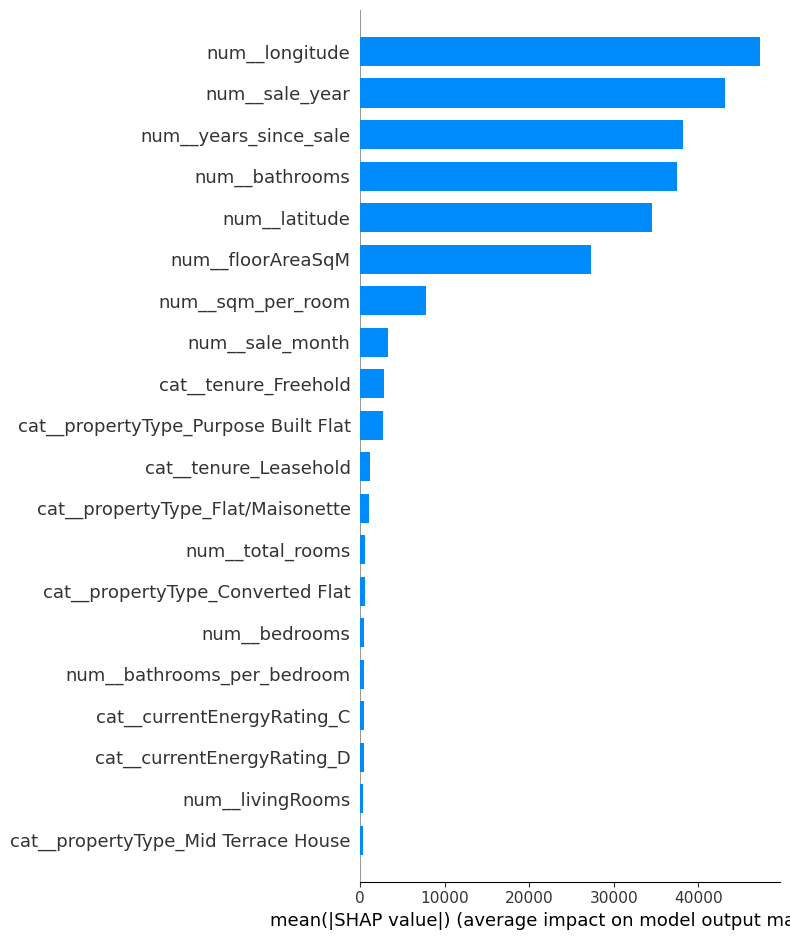

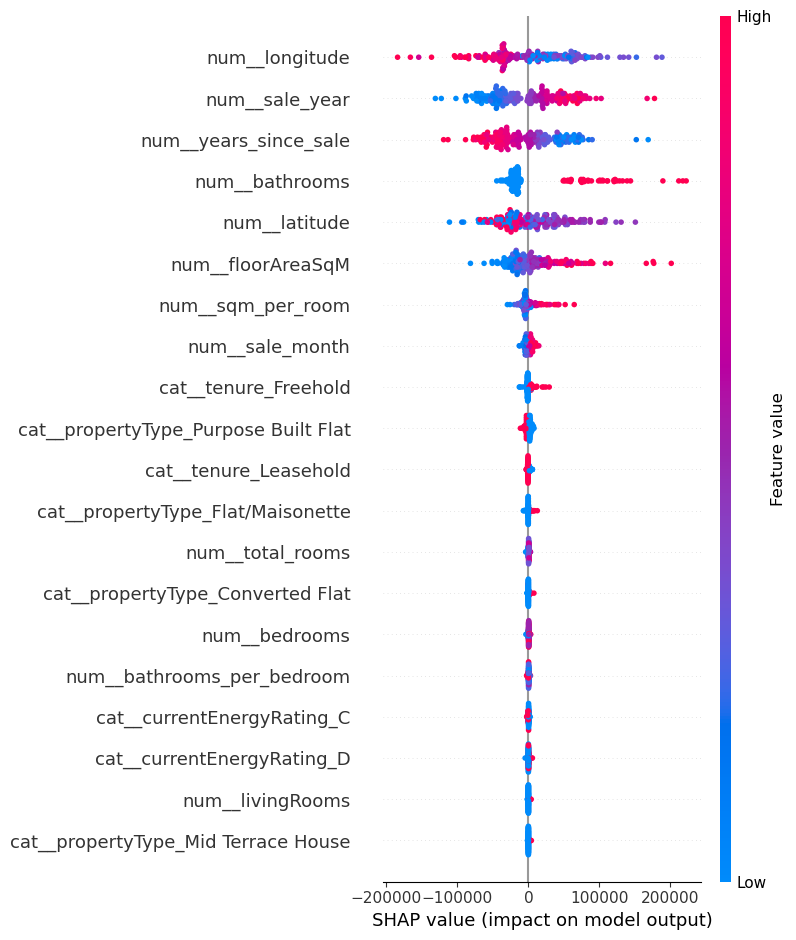

SHAP Analysis: Medium price cluster


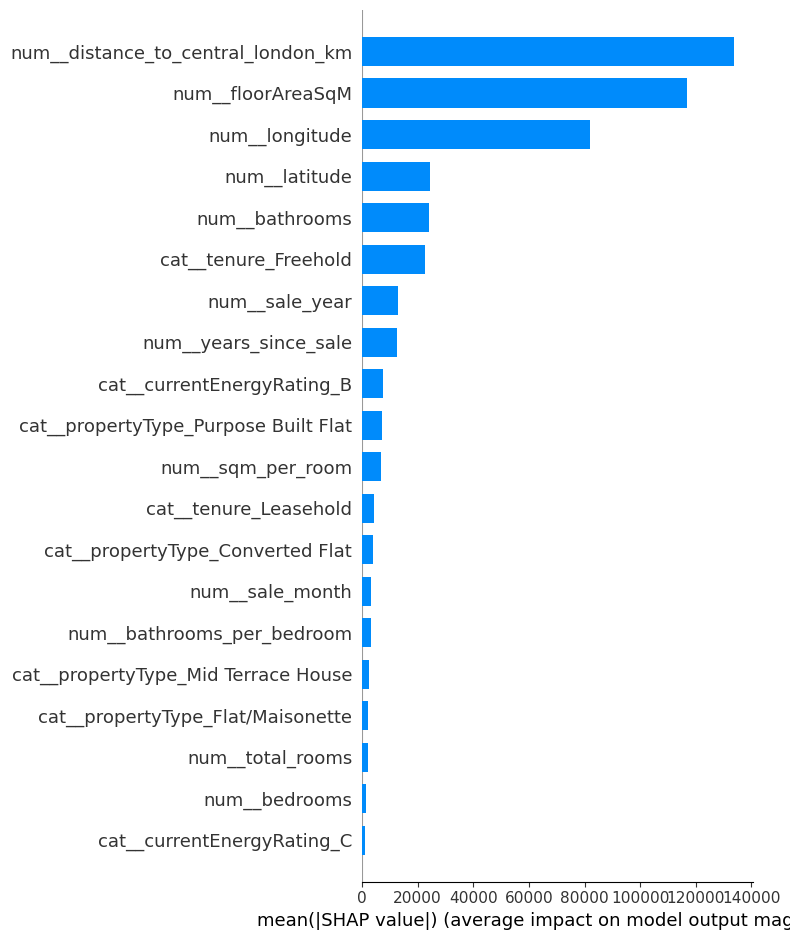

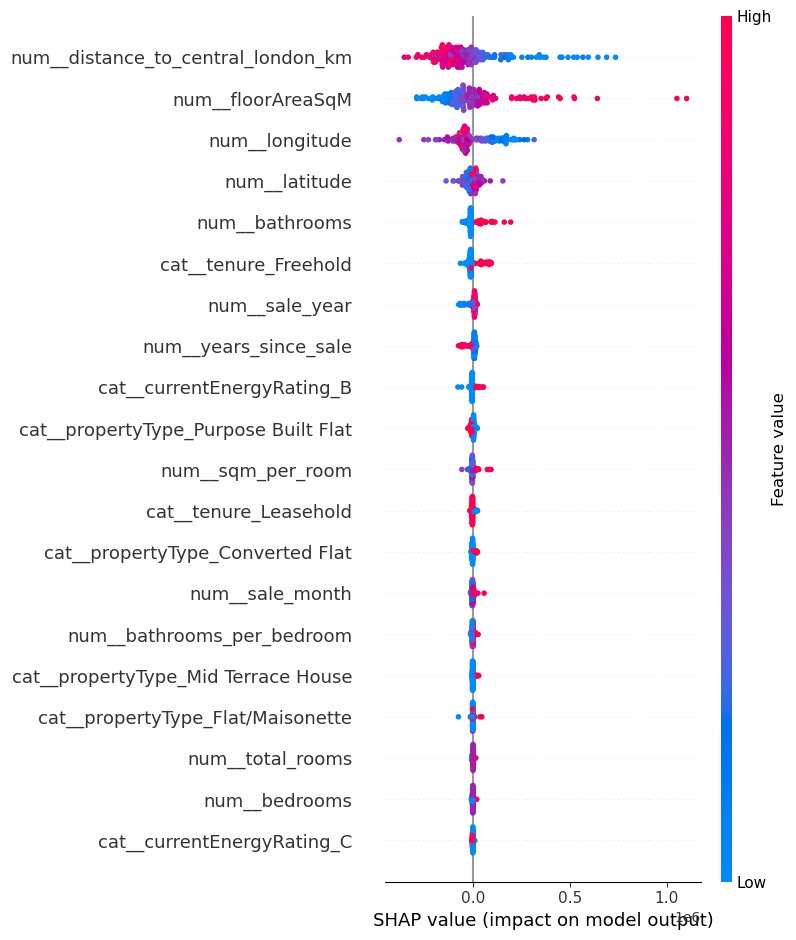

SHAP Analysis: High price cluster


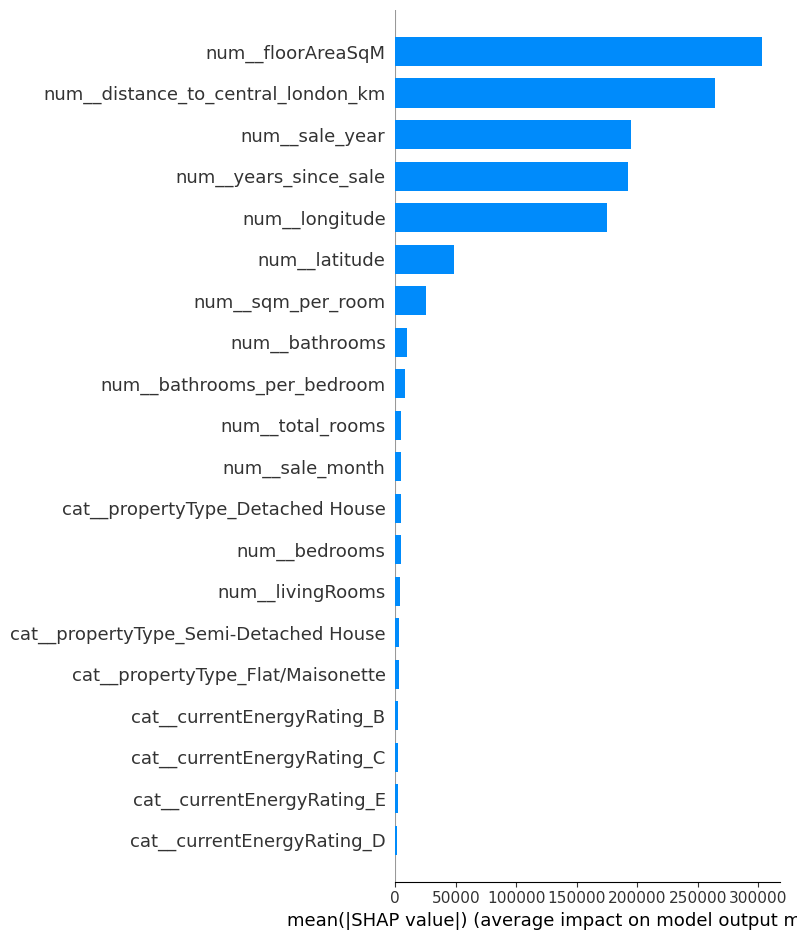

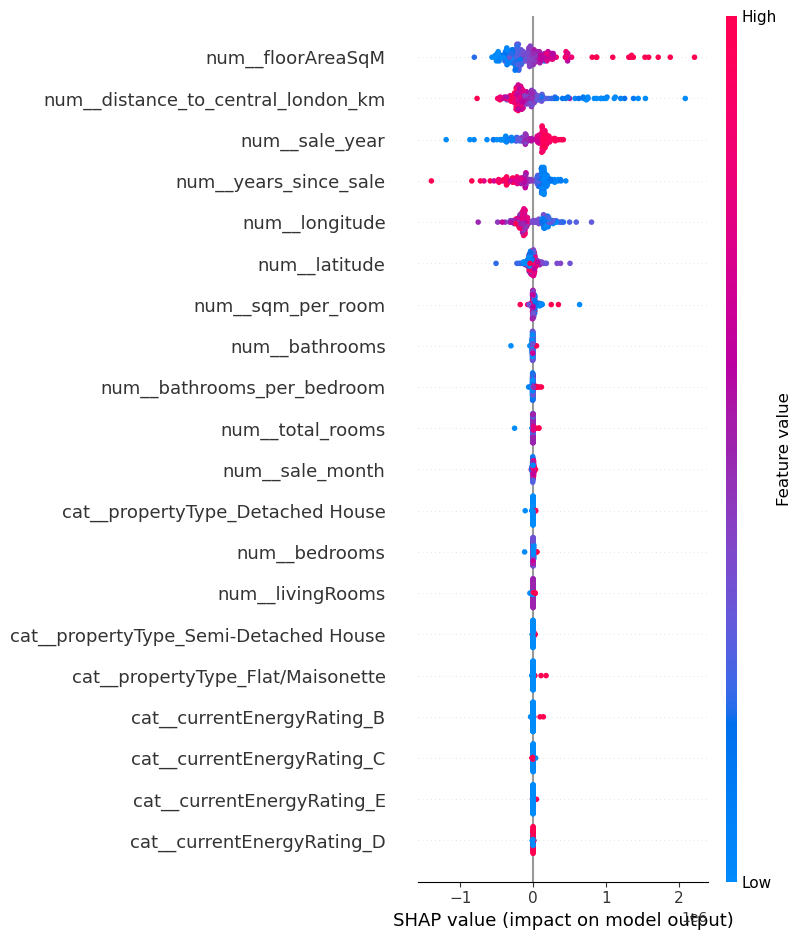

In [148]:
# ============================================================
# SHAP Analysis
# Low, Medium, and High Price Clusters
# ============================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocess"]
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder" or transformer == "drop":
            continue

        if transformer == "passthrough":
            feature_names.extend(columns)

        elif hasattr(transformer, "get_feature_names_out"):
            try:
                feature_names.extend(transformer.get_feature_names_out(columns))
            except:
                feature_names.extend(transformer.get_feature_names_out())

        elif hasattr(transformer, "named_steps"):
            final_step = list(transformer.named_steps.values())[-1]
            if hasattr(final_step, "get_feature_names_out"):
                try:
                    feature_names.extend(final_step.get_feature_names_out(columns))
                except:
                    feature_names.extend(final_step.get_feature_names_out())
            else:
                feature_names.extend(columns)

        else:
            feature_names.extend(columns)

    return list(feature_names)


def run_cluster_shap(
    cluster_name,
    sample_size=200,
    random_state=9
):
    print("=" * 70)
    print(f"SHAP Analysis: {cluster_name}")
    print("=" * 70)

    model_pipeline = final_models[cluster_name]

    preprocessor = model_pipeline.named_steps["preprocess"]
    model = model_pipeline.named_steps["model"]

    cluster_id = [
        k for k, v in cluster_name_map_final.items()
        if v == cluster_name
    ][0]

    X_cluster = (
        X_final_test[X_final_test["cluster"] == cluster_id]
        .drop(columns="cluster")
        .copy()
    )

    # Use columns specific to this fitted cluster model
    required_cols = list(preprocessor.feature_names_in_)

    missing_cols = [
        col for col in required_cols
        if col not in X_cluster.columns
    ]

    if missing_cols:
        raise ValueError(
            f"{cluster_name} is missing columns required by its model: {missing_cols}"
        )

    X_cluster = X_cluster[required_cols]

    sample_n = min(sample_size, len(X_cluster))

    X_sample = X_cluster.sample(
        n=sample_n,
        random_state=random_state
    )

    X_sample_transformed = preprocessor.transform(X_sample)

    if hasattr(X_sample_transformed, "toarray"):
        X_sample_transformed = X_sample_transformed.toarray()

    feature_names = preprocessor.get_feature_names_out()

    X_sample_shap = pd.DataFrame(
        X_sample_transformed,
        columns=feature_names
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample_shap)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_shap,
        plot_type="bar",
        show=True
    )

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_shap,
        show=True
    )

    return {
        "cluster": cluster_name,
        "required_cols": required_cols,
        "pipeline": model_pipeline,
        "X_sample_shap": X_sample_shap,
        "shap_values": shap_values,
        "explainer": explainer
    }


low_shap_results = run_cluster_shap("Low price cluster")
medium_shap_results = run_cluster_shap("Medium price cluster")
high_shap_results = run_cluster_shap("High price cluster")



In [149]:
import numpy as np
import pandas as pd

def shap_top_features_table(shap_results, top_n=5):
    X_sample_shap = shap_results["X_sample_shap"]
    shap_values = shap_results["shap_values"]
    cluster_name = shap_results["cluster"]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.DataFrame({
        "Feature": X_sample_shap.columns,
        "Mean_Abs_SHAP": mean_abs_shap
    })

    shap_importance["Relative_Importance_%"] = (
        shap_importance["Mean_Abs_SHAP"] /
        shap_importance["Mean_Abs_SHAP"].sum()
        * 100
    )

    shap_importance = (
        shap_importance
        .sort_values("Mean_Abs_SHAP", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    shap_importance.insert(0, "Cluster", cluster_name)
    shap_importance.insert(1, "Rank", shap_importance.index + 1)

    return shap_importance


low_top5 = shap_top_features_table(low_shap_results, top_n=5)
medium_top5 = shap_top_features_table(medium_shap_results, top_n=5)
high_top5 = shap_top_features_table(high_shap_results, top_n=5)

shap_top5_table = pd.concat(
    [low_top5, medium_top5, high_top5],
    ignore_index=True
)

shap_top5_table["Relative_Importance_%"] = (
    shap_top5_table["Relative_Importance_%"].round(2)
)

shap_top5_table

,Cluster,Rank,Feature,Mean_Abs_SHAP,Relative_Importance_%
0,Low price cluster,1,num__longitude,47295.6991060192,18.8400000000
1,Low price cluster,2,num__sale_year,43158.9175274472,17.2000000000
2,Low price cluster,3,num__years_since_sale,38229.1550280903,15.2300000000
3,Low price cluster,4,num__bathrooms,37476.5327591500,14.9300000000
4,Low price cluster,5,num__latitude,34533.4753801380,13.7600000000
5,Medium price cluster,1,num__distance_to_central_london_km,133751.0731060657,28.0300000000
6,Medium price cluster,2,num__floorAreaSqM,116711.7183113038,24.4600000000
7,Medium price cluster,3,num__longitude,81964.7941398468,17.1800000000
8,Medium price cluster,4,num__latitude,24531.1383151313,5.1400000000
9,Medium price cluster,5,num__bathrooms,23977.0509144306,5.0200000000


In [150]:
feature_name_map = {
    "num__longitude": "Longitude",
    "num__latitude": "Latitude",
    "num__sale_year": "Sale year",
    "num__years_since_sale": "Years since sale",
    "num__bathrooms": "Bathrooms",
    "num__floorAreaSqM": "Floor area",
    "num__sqm_per_room": "Square metres per room",
    "num__distance_to_central_london_km": "Distance to Central London",
    "num__total_rooms": "Total rooms",
    "num__bedrooms": "Bedrooms",
    "num__livingRooms": "Living rooms",
    "cat__tenure_Freehold": "Freehold tenure",
    "cat__tenure_Leasehold": "Leasehold tenure",
    "cat__propertyType_Purpose Built Flat": "Purpose-built flat",
    "cat__propertyType_Flat/Maisonette": "Flat/Maisonette",
    "cat__currentEnergyRating_B": "Energy rating B",
    "cat__currentEnergyRating_C": "Energy rating C",
    "cat__currentEnergyRating_D": "Energy rating D",
}

shap_top5_table["Feature"] = (
    shap_top5_table["Feature"]
    .replace(feature_name_map)
)

shap_top5_table

,Cluster,Rank,Feature,Mean_Abs_SHAP,Relative_Importance_%
0,Low price cluster,1,Longitude,47295.6991060192,18.8400000000
1,Low price cluster,2,Sale year,43158.9175274472,17.2000000000
2,Low price cluster,3,Years since sale,38229.1550280903,15.2300000000
3,Low price cluster,4,Bathrooms,37476.5327591500,14.9300000000
4,Low price cluster,5,Latitude,34533.4753801380,13.7600000000
5,Medium price cluster,1,Distance to Central London,133751.0731060657,28.0300000000
6,Medium price cluster,2,Floor area,116711.7183113038,24.4600000000
7,Medium price cluster,3,Longitude,81964.7941398468,17.1800000000
8,Medium price cluster,4,Latitude,24531.1383151313,5.1400000000
9,Medium price cluster,5,Bathrooms,23977.0509144306,5.0200000000


In [154]:
# Low-price cluster table
print("Table X: Top 5 SHAP Features — Low-Price Cluster")

display(
    shap_top5_table[
        shap_top5_table["Cluster"] == "Low price cluster"
    ][["Rank", "Feature", "Relative_Importance_%"]]
    .rename(columns={
        "Relative_Importance_%": "Relative Importance (%)"
    })
    .reset_index(drop=True)
)

Table X: Top 5 SHAP Features — Low-Price Cluster


,Rank,Feature,Relative Importance (%)
0,1,Longitude,18.8400000000
1,2,Sale year,17.2000000000
2,3,Years since sale,15.2300000000
3,4,Bathrooms,14.9300000000
4,5,Latitude,13.7600000000


In [155]:
# Medium-price cluster table
print("Table X: Top 5 SHAP Features — Medium-Price Cluster")

display(
    shap_top5_table[
        shap_top5_table["Cluster"] == "Medium price cluster"
    ][["Rank", "Feature", "Relative_Importance_%"]]
    .rename(columns={
        "Relative_Importance_%": "Relative Importance (%)"
    })
    .reset_index(drop=True)
)

Table X: Top 5 SHAP Features — Medium-Price Cluster


,Rank,Feature,Relative Importance (%)
0,1,Distance to Central London,28.0300000000
1,2,Floor area,24.4600000000
2,3,Longitude,17.1800000000
3,4,Latitude,5.1400000000
4,5,Bathrooms,5.0200000000


In [156]:
# High-price cluster table
print("Table X: Top 5 SHAP Features — High-Price Cluster")

display(
    shap_top5_table[
        shap_top5_table["Cluster"] == "High price cluster"
    ][["Rank", "Feature", "Relative_Importance_%"]]
    .rename(columns={
        "Relative_Importance_%": "Relative Importance (%)"
    })
    .reset_index(drop=True)
)

Table X: Top 5 SHAP Features — High-Price Cluster


,Rank,Feature,Relative Importance (%)
0,1,Floor area,24.0100000000
1,2,Distance to Central London,20.9400000000
2,3,Sale year,15.4300000000
3,4,Years since sale,15.2500000000
4,5,Longitude,13.8900000000


The SHAP results demonstrated that different housing-market segments relied on different predictive drivers. Lower-priced housing was influenced more heavily by geographic and temporal variables, while medium- and high-priced segments relied more strongly on floor area and proximity to Central London. These findings further supported the use of segmented modelling approaches by demonstrating that different market segments exhibited distinct pricing dynamics